In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# 经典天气预测马尔可夫链（案例1）
states_weather = ['Sunny', 'Rainy']
P_weather = np.array([[0.8, 0.2], [0.4, 0.6]])

# 加载MNIST数据集（经典数据集）
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1000, shuffle=True)

# 将MNIST标签加载为完整序列
mnist_data = []
for images, labels in mnist_loader:
    mnist_data.append(labels)
mnist_data = torch.cat(mnist_data).numpy()  # 整个MNIST训练集的标签

# 1. Temporal Markov Transformer (TMT) 定义
class TMT(nn.Module):
    def __init__(self, num_states, hidden_dim=64, num_heads=4, num_layers=2):
        super(TMT, self).__init__()
        self.embedding = nn.Embedding(num_states, hidden_dim)  # 状态嵌入
        transformer_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_states)  # 输出转移概率

    def forward(self, x):
        # x: [seq_len, batch_size] -> [seq_len, batch_size, hidden_dim]
        x = self.embedding(x)
        x = self.transformer(x)  # Transformer处理序列
        x = self.fc(x)  # 输出每个状态的logits
        return torch.softmax(x, dim=-1)  # 转换为概率

# 2. 计算经典马尔可夫链的稳态分布
def compute_stationary_distribution(P):
    eigenvalues, eigenvectors = np.linalg.eig(P.T)
    stationary = eigenvectors[:, np.isclose(eigenvalues, 1)].real
    return (stationary / stationary.sum()).flatten()

# 3. 模拟经典马尔可夫链路径
def simulate_markov_chain(P, initial_state, steps):
    state = initial_state
    path = [state]
    for _ in range(steps - 1):
        next_state = np.random.choice(len(P), p=P[state])
        path.append(next_state)
        state = next_state
    return path

# 4. 使用TMT生成动态转移概率并模拟路径
def simulate_tmt_path(model, initial_state, steps, device='cpu'):
    model.eval()
    state = torch.tensor([initial_state], dtype=torch.long).to(device)
    path = [initial_state]
    with torch.no_grad():
        for _ in range(steps - 1):
            # 输入需要是 [seq_len=1, batch_size=1]
            input_seq = state.unsqueeze(1)  # [1, 1]
            probs = model(input_seq.squeeze(1)).squeeze(0)[-1]  # 获取最新状态的转移概率
            next_state = torch.multinomial(probs, 1).item()
            path.append(next_state)
            state = torch.tensor([next_state], dtype=torch.long).to(device)
    return path

# 5. 统计频率
def compute_state_frequencies(path, num_states):
    counts = np.bincount(path, minlength=num_states)
    return counts / len(path)

# 主程序
def main():
    # --- 经典天气预测马尔可夫链 ---
    print("=== 经典马尔可夫链：天气预测 ===")
    pi_weather = compute_stationary_distribution(P_weather)
    for state, prob in zip(states_weather, pi_weather):
        print(f"{state}: {prob:.4f}")

    path_weather = simulate_markov_chain(P_weather, 0, 1000)
    freq_weather = compute_state_frequencies(path_weather, len(states_weather))
    print("\n模拟频率:")
    for state, freq in zip(states_weather, freq_weather):
        print(f"{state}: {freq:.4f}")

    # --- MNIST数字序列预测（TMT） ---
    print("\n=== TMT深度学习：MNIST数字序列预测 ===")
    states_mnist = list(range(10))  # 0-9数字作为状态
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 初始化TMT模型
    tmt_model = TMT(num_states=10).to(device)
    optimizer = torch.optim.Adam(tmt_model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 简单训练TMT（基于MNIST标签序列）
    print("训练TMT模型...")
    for epoch in range(5):  # 假设5个epoch
        tmt_model.train()
        total_loss = 0
        for i in range(0, len(mnist_data) - 11, 10):  # 步长10取序列，确保i+10不会超过len(mnist_data)
            seq = torch.tensor(mnist_data[i:i+10], dtype=torch.long).to(device)
            target = torch.tensor(mnist_data[i+1:i+11], dtype=torch.long).to(device)
            optimizer.zero_grad()
            output = tmt_model(seq[:-1].unsqueeze(1))  # 输入形状 [9, 1]
            target = target[:-1]  # 目标形状 [9]
            loss = criterion(output.squeeze(1), target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # 使用训练好的TMT模拟路径
    path_mnist = simulate_tmt_path(tmt_model, 0, 1000, device)
    freq_mnist = compute_state_frequencies(path_mnist, 10)
    print("\nTMT模拟频率 (MNIST数字 0-9):")
    for state, freq in zip(states_mnist, freq_mnist):
        print(f"Digit {state}: {freq:.4f}")

    # 可视化
    plt.figure(figsize=(12, 8))
    
    # 天气路径与频率
    plt.subplot(2, 2, 1)
    plt.plot(path_weather[:100], 'o-', label='Weather Path')
    plt.yticks([0, 1], states_weather)
    plt.title('Classic MC: Weather Path (First 100 Steps)')
    plt.xlabel('Step')
    plt.ylabel('State')
    plt.legend()

    plt.subplot(2, 2, 2)
    x = np.arange(len(states_weather))
    plt.bar(x - 0.2, pi_weather, 0.4, label='Stationary', color='blue')
    plt.bar(x + 0.2, freq_weather, 0.4, label='Simulated', color='orange')
    plt.xticks(x, states_weather)
    plt.title('Weather: Stationary vs Simulated')
    plt.legend()

    # MNIST路径与频率
    plt.subplot(2, 2, 3)
    plt.plot(path_mnist[:100], 'o-', label='MNIST Path')
    plt.yticks(states_mnist)
    plt.title('TMT: MNIST Digit Path (First 100 Steps)')
    plt.xlabel('Step')
    plt.ylabel('Digit')
    plt.legend()

    plt.subplot(2, 2, 4)
    x = np.arange(10)
    plt.bar(x, freq_mnist, label='TMT Simulated', color='green')
    plt.xticks(x, states_mnist)
    plt.title('MNIST: TMT Simulated Frequencies')
    plt.ylabel('Frequency')
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

=== 经典马尔可夫链：天气预测 ===
Sunny: 0.6667
Rainy: 0.3333

模拟频率:
Sunny: 0.6740
Rainy: 0.3260

=== TMT深度学习：MNIST数字序列预测 ===
训练TMT模型...


d:\Users\wangp\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Loss: 13712.6156
Epoch 2, Loss: 13677.5518


KeyboardInterrupt: 

In [2]:
import bisect
import functools
import logging
import math
import re
from dataclasses import dataclass
from typing import Any, Callable, NamedTuple, Optional, Tuple

import haiku as hk
import jax
import jax.experimental.pjit as pjit
import jax.numpy as jnp
import numpy as np
from jax.experimental import mesh_utils
from jax.sharding import PartitionSpec as P
from jax.typing import ArrayLike

import checkpoint as xai_checkpoint
from model import (
    LanguageModelConfig,
    LanguageModelOutput,
    TrainingState,
    KVMemory,
    Memory,
)

logger = logging.getLogger(__name__)
rank_logger = logging.getLogger("rank")

TOP_K = 8  # Parameterized for flexibility


class SampleSettings(NamedTuple):
    temperature: ArrayLike
    nucleus_p: ArrayLike
    mask: ArrayLike
    active: ArrayLike  # [B]


class SampleOutput(NamedTuple):
    token_id: ArrayLike
    prob: ArrayLike
    top_k_token_ids: ArrayLike
    top_k_probs: ArrayLike


def insert_slice(memory: Memory, slice_mem, length, i):
    slice_mem = Memory(
        layers=[
            KVMemory(layer.k, layer.v, step=jnp.array([length]))
            for layer in slice_mem.layers
        ],
    )

    return jax.tree_map(
        lambda m, u: jax.lax.dynamic_update_index_in_dim(m, u[0], i, axis=0),
        memory,
        slice_mem,
    )


def pad_to_size(x, size):
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(
        x, [0, size - x.shape[0]], mode="constant", constant_values=0
    )


def top_p_filter(logits: jax.Array, top_p: jax.Array) -> jax.Array:
    assert logits.ndim == top_p.ndim, f"Expected {logits.ndim} equal {top_p.ndim}"
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(
        jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1
    )
    threshold_largest_logits = jnp.take_along_axis(
        sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1
    )
    mask = logits >= threshold_largest_logits
    logits = jnp.where(mask, logits, -jnp.inf)
    return logits


def sample_token(
    rngs: jax.random.PRNGKey,
    lm_outputs: LanguageModelOutput,
    settings: SampleSettings,
) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(
        lm_outputs.logits.dtype
    )
    logits = jnp.where(
        settings.mask, logits, jnp.where(settings.mask, logits, -jnp.inf)
    )
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)

    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(
        probabilities,
        jnp.expand_dims(new_token, 1),
        axis=2,
    )
    token_prob = jnp.squeeze(token_prob, 1)

    top_k_probs, top_k_token_ids = jax.lax.top_k(
        probabilities, TOP_K
    )
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(
        new_token,
        token_prob,
        top_k_token_ids,
        top_k_probs,
    )


@dataclass
class ModelRunner:
    model: LanguageModelConfig
    bs_per_device: float = 2.0
    load_rename_rules: Optional[list[tuple[str, str]]] = None
    load_exclude_rules: Optional[list[str]] = None
    rng_seed: int = 42
    transform_forward: bool = False
    checkpoint_path: str = ""

    def make_forward_fn(self, mesh: Any):
        def forward(tokens):
            out = self.model.make(mesh=mesh)(tokens)
            return out, None

        if self.transform_forward:
            forward = hk.transform(forward)
        return forward

    def initialize(
        self,
        init_data,
        local_mesh_config: tuple[int, int],
        between_hosts_config: tuple[int, int],
    ):
        num_replicas = math.prod(between_hosts_config)
        self.model.initialize()
        self.model.fprop_dtype = jnp.bfloat16
        num_local_gpus = len(jax.local_devices())
        self.batch_size = int(
            self.bs_per_device * num_local_gpus * num_replicas
        )
        self.local_batch_size = self.batch_size // jax.process_count()
        self.local_mesh_config = local_mesh_config
        self.between_hosts_config = between_hosts_config
        rank_logger.info(
            f"Initializing mesh for local_mesh_config={self.local_mesh_config}, between_hosts_config={self.between_hosts_config}..."
        )
        self.mesh = make_mesh(
            self.local_mesh_config, self.between_hosts_config
        )
        self.forward = self.make_forward_fn(mesh=self.mesh)
        self.logits_fn = hk.transform(lambda tokens: self.forward(tokens)[0])
        self.eval_forward = self.make_forward_fn(mesh=self.mesh)
        self.logits_eval_fn = hk.transform(
            lambda tokens: self.eval_forward(tokens)[0]
        )

        if self.transform_forward:
            self.state_sharding = self.get_state_sharding(init_data)
            rank_logger.info(
                f"State sharding type: {type(self.state_sharding)}"
            )
            self.init_fn = pjit.pjit(
                self.init, out_shardings=self.state_sharding
            )

    def init(self, rng: jax.Array, data) -> TrainingState:
        assert self.transform_forward
        rng, init_rng = jax.random.split(rng)
        params = self.forward.init(init_rng, data["inputs"])
        return TrainingState(params=params)

    def get_state_sharding(self, init_data):
        assert self.transform_forward
        rng = jax.random.PRNGKey(self.rng_seed)
        with self.mesh:
            shapes = jax.eval_shape(self.init, rng, init_data)
            sharding = jax.tree_util.tree_map_with_path(
                apply_rules(self.model.partition_rules()), shapes
            )
        return sharding

    def load_or_init(
        self,
        init_data: Any,
        from_checkpoint: bool = True,
        init_fn: Optional[Callable] = None,
    ):
        rng = jax.random.PRNGKey(self.rng_seed)

        if not self.checkpoint_path or not from_checkpoint:
            rank_logger.info("Initializing model...")
            with self.mesh:
                if init_fn is not None:
                    state = init_fn(rng, init_data)
                else:
                    assert self.transform_forward
                    state = self.init_fn(rng, init_data)
            rank_logger.info("Model state is newly initialized.")
        else:
            with self.mesh:
                if init_fn:
                    state_shapes = jax.eval_shape(init_fn, rng, init_data)
                else:
                    assert self.transform_forward
                    state_shapes = jax.eval_shape(
                        self.init_fn, rng, init_data
                    )
            init_state = None

            state = xai_checkpoint.restore(
                checkpoint_path=self.checkpoint_path,
                state_shapes=state_shapes,
                mesh=self.mesh,
                between_hosts_config=self.between_hosts_config,
                state_sharding=self.state_sharding,
                init_state=init_state,
                params_only=True,
            )

            del init_state
        return state


@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int


@dataclass
class InferenceRunner:
    name: str
    runner: Any
    load: str
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"
    local_mesh_config: Tuple[int, int] = (1, 1)
    between_hosts_config: Tuple[int, int] = (1, 1)
    pad_sizes: tuple[int] = (1024,)

    def get_pad_bucket(self, size):
        i = bisect.bisect_left(self.pad_sizes, size)
        return self.pad_sizes[min(i, len(self.pad_sizes) - 1)]

    def initialize(self):
        runner = self.runner
        self.runner.transform_forward = True
        dummy_data = dict(
            inputs=np.zeros((1, 256), dtype=np.int32),
            targets=np.zeros((1, 256), dtype=np.int32),
        )
        runner.initialize(
            dummy_data,
            local_mesh_config=self.local_mesh_config,
            between_hosts_config=self.between_hosts_config,
        )

        self.tokenizer = sentencepiece.SentencePieceProcessor(
            model_file=self.tokenizer_path
        )

        max_len = runner.model.sequence_len
        self.vocab_size = runner.model.vocab_size

        params = runner.load_or_init(dummy_data)
        self.params = params

        def pad_to_max_len(x):
            if len(x.shape) > 1:
                pad_width = max_len - x.shape[1]
                return jnp.pad(
                    x, [(0, 0), (0, pad_width), (0, 0), (0, 0)]
                )
            else:
                return x

        @functools.lru_cache
        def lm():
            return runner.model.make(mesh=runner.mesh)

        def hk_forward(
            tokens, memory=None, length=None, active=None
        ) -> LanguageModelOutput:
            if memory is not None:
                assert active is not None
                layers = []
                for l in memory.layers:
                    step = jnp.where(active, l.step, jnp.zeros_like(l.step))
                    layers.append(l._replace(step=step))
                memory = memory._replace(layers=layers)
            return lm()(tokens, memory, length=length)

        def hk_sample_step(
            rngs, last_output: SampleOutput, memory, settings
        ):
            rngs, rngs_ = jax.vmap(jax.random.split, out_axes=1)(rngs)
            lm_outputs = hk_forward(
                last_output.token_id, memory=memory, active=settings.active
            )
            sample_result = sample_token(rngs_, lm_outputs, settings)
            return rngs, sample_result, lm_outputs.model_state

        def hk_new_memory(batch_size, sequence_len):
            return lm().init_memory(batch_size, sequence_len)

        def hk_prefill_memory(
            rngs,
            memory,
            settings,
            last_output,
            prompt,
            length,
            rng_seed,
            new_settings,
            i,
        ):
            rng = jax.random.PRNGKey(seed=rng_seed)
            rng, rng_ = jax.random.split(rng)

            slice = hk_new_memory(1, prompt.shape[0])
            settings_slice = jax.tree_map(
                lambda t: jnp.expand_dims(t[i], axis=0), settings
            )

            lm_outputs = hk_forward(
                jnp.expand_dims(prompt, 0),
                memory=slice,
                length=jnp.expand_dims(length, 0),
                active=settings_slice.active,
            )

            slice = lm_outputs.model_state
            slice = slice._replace(
                layers=[
                    l._replace(step=jnp.array([length]))
                    for l in slice.layers
                ]
            )

            rng_ = jnp.expand_dims(rng_, 0)
            new_output = sample_token(rng_, lm_outputs, settings_slice)

            slice = jax.tree_map(pad_to_max_len, slice)
            memory = insert_slice(memory, slice, length, i)

            rng = jnp.expand_dims(rng, 0)
            rngs = jax.lax.dynamic_update_index_in_dim(
                rngs, rng, i, axis=0
            )

            last_output = jax.tree_util.tree_map(
                lambda last, new: jax.lax.dynamic_update_index_in_dim(
                    last, new, i, axis=0
                ),
                last_output,
                new_output,
            )
            return rngs, last_output, memory, settings

        sample_step_ = hk.without_apply_rng(hk.transform(hk_sample_step))
        prefill_memory_ = hk.without_apply_rng(hk.transform(hk_prefill_memory))
        new_memory_ = hk.without_apply_rng(hk.transform(hk_new_memory))
        forward_ = hk.without_apply_rng(hk.transform(hk_forward))

        rng = jax.random.PRNGKey(42)
        dummy_tokens = jnp.zeros((1, max_len), jnp.int32)

        with runner.mesh:
            shapes = jax.eval_shape(forward_.init, rng, dummy_tokens)

        self.params_sharding = jax.tree_util.tree_map_with_path(
            apply_rules(runner.model.partition_rules()), shapes
        )

        ds = P("data")
        ms = runner.model.model.get_memory_sharding()
        self.sample_step = pjit.pjit(
            sample_step_.apply,
            in_shardings=(self.params_sharding, None, ds, ms, None),
            out_shardings=(None, ds, ms),
            donate_argnums=3,
        )
        self.prefill_memory = pjit.pjit(
            functools.partial(prefill_memory_.apply),
            in_shardings=(
                self.params_sharding,
                None,
                ms,
                None,
                ds,
                None,
                None,
                None,
                None,
                None,
            ),
            out_shardings=(None, ds, ms, None),
            donate_argnums=(2,),
        )
        self.new_memory = pjit.pjit(
            new_memory_.apply,
            static_argnums=(1, 2),
            out_shardings=ms,
        )

    def run(self):
        runner = self.runner
        mesh = runner.mesh
        max_len = runner.model.sequence_len
        batch_size = runner.batch_size
        params = self.params
        rngs = jax.random.split(jax.random.PRNGKey(1), batch_size)
        with mesh:
            memory = self.new_memory(params, batch_size, max_len)
            settings = SampleSettings(
                temperature=np.zeros((batch_size,), dtype=np.float32),
                nucleus_p=np.zeros((batch_size,), dtype=np.float32),
                mask=np.ones((batch_size, self.vocab_size), dtype=np.int32),
                active=np.zeros((batch_size), dtype=np.int32),
            )
            last_output = SampleOutput(
                token_id=np.zeros((batch_size, 1), dtype=np.int32),
                prob=np.zeros((batch_size, 1), dtype=jnp.bfloat16),
                top_k_token_ids=np.zeros((batch_size, TOP_K), dtype=np.int32),
                top_k_probs=np.zeros((batch_size, TOP_K), dtype=jnp.bfloat16),
            )

            prompt = np.array([300, 400, 500, 600, 600, 700, 800])

            new_settings = SampleSettings(
                temperature=np.float32(1),
                nucleus_p=np.float32(1),
                mask=np.ones((self.vocab_size,), dtype=np.int32),
                active=np.zeros((), dtype=np.int32),
            )
            rng_seed = np.uint64(1)

            for size in self.pad_sizes:
                if size > runner.model.sequence_len:
                    break
                logger.info(f"Precompile {size}")
                prompt_len = len(prompt)
                prompt = pad_to_size(prompt, self.get_pad_bucket(prompt.shape[0]))
                rngs, last_output, memory, settings = self.prefill_memory(
                    params,
                    rngs,
                    memory,
                    settings,
                    last_output,
                    prompt,
                    prompt_len,
                    rng_seed,
                    new_settings,
                    0,
                )
        with runner.mesh:
            logger.info("Compiling...")
            rngs, last_output, memory = self.sample_step(
                params, rngs, last_output, memory, settings
            )
            logger.info("Done compiling.")

        all_tokens = []
        free_slots = list(range(batch_size))
        requests = [None] * batch_size
        first_output = [None] * batch_size
        jax.tree_map(lambda x: x.copy_to_host_async(), last_output)
        prev_token = last_output
        step = 0
        total_num_tokens = 0
        total_num_sequences = 0
        with mesh:
            while True:
                while free_slots:
                    request: Optional[Request] = yield
                    tokens = self.tokenizer.encode(request.prompt)
                    temperature = request.temperature
                    nucleus_p = request.nucleus_p
                    rng_seed = request.rng_seed

                    i = free_slots.pop()
                    prompt = np.array(tokens, dtype=np.int32)
                    prompt_len = len(prompt)
                    prompt = pad_to_size(
                        prompt, self.get_pad_bucket(prompt.shape[0])
                    )
                    mask = np.ones((self.vocab_size,), dtype=np.int32)

                    new_settings = SampleSettings(
                        temperature=np.float32(temperature),
                        nucleus_p=np.float32(nucleus_p),
                        mask=mask,
                        active=1,
                    )
                    rng_seed = np.uint64(rng_seed)
                    rngs, last_output, memory, settings = self.prefill_memory(
                        params,
                        rngs,
                        memory,
                        settings,
                        last_output,
                        prompt,
                        prompt_len,
                        rng_seed,
                        new_settings,
                        i,
                    )
                    jax.tree_map(lambda x: x.copy_to_host_async(), last_output)
                    first_output[i] = last_output
                    requests[i] = request
                    total_num_sequences += 1

                rngs, last_output, memory = self.sample_step(
                    params, rngs, last_output, memory, settings
                )
                total_num_tokens += batch_size - len(free_slots)

                prev_token = jax.tree_map(np.array, prev_token)
                for i in range(batch_size):
                    if requests[i] is not None:
                        if first_output[i] is not None:
                            first_output_i = jax.tree_map(
                                np.array, first_output[i]
                            )
                            all_tokens.append(
                                int(first_output_i.token_id[i][0])
                            )
                            first_output[i] = None
                            continue

                        all_tokens.append(int(prev_token.token_id[i][0]))
                        cont = len(all_tokens) < requests[i].max_len

                        if not cont:
                            output_str = self.tokenizer.decode(all_tokens)
                            requests[i] = None
                            free_slots.append(i)
                            all_tokens = []
                            settings = settings._replace(
                                active=settings.active.at[i].set(0)
                            )
                            yield output_str

                jax.tree_map(lambda x: x.copy_to_host_async(), last_output)
                prev_token = last_output
                step += 1


def make_mesh(
    local_mesh_config: tuple[int, int], between_hosts_config: tuple[int, int]
) -> jax.sharding.Mesh:
    device_mesh = mesh_utils.create_hybrid_device_mesh(
        local_mesh_config,
        between_hosts_config,
        devices=jax.devices(),
        process_is_granule=True,
    )
    rank_logger.debug(
        f"Job device mesh is:\n{device_mesh}"
    )
    return jax.sharding.Mesh(device_mesh, ("data", "model"))


def sample_from_model(server, prompt, max_len, temperature):
    next(server)
    inp = Request(
        prompt=prompt,
        temperature=temperature,
        nucleus_p=1.0,
        rng_seed=42,
        max_len=max_len,
    )
    return server.send(inp)

ModuleNotFoundError: No module named 'haiku'

In [3]:
pip install dm-haiku

Note: you may need to restart the kernel to use updated packages.


In [4]:
import bisect
import functools
import logging
import math
import re
from dataclasses import dataclass
from typing import Any, Callable, NamedTuple, Optional, Tuple

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
from jax.typing import ArrayLike

# 如果需要使用checkpoint模块，需要确保该模块已正确安装或实现
import checkpoint as xai_checkpoint
from model import (
    LanguageModelConfig,
    LanguageModelOutput,
    TrainingState,
    KVMemory,
    Memory,
)

logger = logging.getLogger(__name__)
rank_logger = logging.getLogger("rank")

TOP_K = 8  # 参数化，可以根据需要调整


class SampleSettings(NamedTuple):
    """采样设置，包含温度、核概率、掩码和激活状态"""
    temperature: ArrayLike
    nucleus_p: ArrayLike
    mask: ArrayLike
    active: ArrayLike  # [B]


class SampleOutput(NamedTuple):
    """采样输出，包含采样到的token ID、概率、Top-K token IDs和概率"""
    token_id: ArrayLike
    prob: ArrayLike
    top_k_token_ids: ArrayLike
    top_k_probs: ArrayLike


def insert_slice(memory: Memory, slice_mem, length, i):
    """将切片插入到内存中"""
    slice_mem = Memory(
        layers=[
            KVMemory(layer.k, layer.v, step=jnp.array([length]))
            for layer in slice_mem.layers
        ],
    )

    return jax.tree_map(
        lambda m, u: jax.lax.dynamic_update_index_in_dim(m, u[0], i, axis=0),
        memory,
        slice_mem,
    )


def pad_to_size(x, size):
    """将数组填充到指定大小"""
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(
        x, [0, size - x.shape[0]], mode="constant", constant_values=0
    )


def top_p_filter(logits: jax.Array, top_p: jax.Array) -> jax.Array:
    """基于核概率的过滤"""
    assert logits.ndim == top_p.ndim, f"Expected {logits.ndim} equal {top_p.ndim}"
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(
        jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1
    )
    threshold_largest_logits = jnp.take_along_axis(
        sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1
    )
    mask = logits >= threshold_largest_logits
    logits = jnp.where(mask, logits, -jnp.inf)
    return logits


def sample_token(
    rngs: jax.random.PRNGKey,
    lm_outputs: LanguageModelOutput,
    settings: SampleSettings,
) -> SampleOutput:
    """根据模型输出和采样设置生成token"""
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(
        lm_outputs.logits.dtype
    )
    logits = jnp.where(
        settings.mask, logits, jnp.where(settings.mask, logits, -jnp.inf)
    )
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)

    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(
        probabilities,
        jnp.expand_dims(new_token, 1),
        axis=2,
    )
    token_prob = jnp.squeeze(token_prob, 1)

    top_k_probs, top_k_token_ids = jax.lax.top_k(
        probabilities, TOP_K
    )
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(
        new_token,
        token_prob,
        top_k_token_ids,
        top_k_probs,
    )


@dataclass
class ModelRunner:
    """模型运行器，负责初始化、加载模型和执行前向传播"""
    model: LanguageModelConfig
    bs_per_device: float = 2.0
    load_rename_rules: Optional[list[tuple[str, str]]] = None
    load_exclude_rules: Optional[list[str]] = None
    rng_seed: int = 42
    transform_forward: bool = False
    checkpoint_path: str = ""

    def make_forward_fn(self):
        """创建模型的前向传播函数"""
        def forward(tokens):
            return self.model.make()(tokens)

        if self.transform_forward:
            forward = hk.transform(forward)
        return forward

    def initialize(self, init_data):
        """初始化模型"""
        self.model.initialize()
        self.model.fprop_dtype = jnp.float32
        self.forward = self.make_forward_fn()
        self.logits_fn = hk.transform(lambda tokens: self.forward(tokens)[0])

        if self.transform_forward:
            self.state_sharding = self.get_state_sharding(init_data)
            self.init_fn = self.init

    def init(self, rng: jax.Array, data) -> TrainingState:
        """初始化模型参数"""
        assert self.transform_forward
        rng, init_rng = jax.random.split(rng)
        params = self.forward.init(init_rng, data["inputs"])
        return TrainingState(params=params)

    def get_state_sharding(self, init_data):
        """获取状态分片规则"""
        assert self.transform_forward
        rng = jax.random.PRNGKey(self.rng_seed)
        shapes = jax.eval_shape(self.init, rng, init_data)
        sharding = jax.tree_util.tree_map_with_path(
            lambda path, shape: None, shapes
        )  # 在CPU环境下，分片规则可以简化为None
        return sharding

    def load_or_init(self, init_data: Any, from_checkpoint: bool = True):
        """加载或初始化模型状态"""
        rng = jax.random.PRNGKey(self.rng_seed)

        if not self.checkpoint_path or not from_checkpoint:
            logger.info("Initializing model from scratch...")
            state = self.init_fn(rng, init_data)
            logger.info("Model initialized.")
        else:
            logger.info("Loading model from checkpoint...")
            state_shapes = jax.eval_shape(self.init_fn, rng, init_data)
            state = xai_checkpoint.restore(
                checkpoint_path=self.checkpoint_path,
                state_shapes=state_shapes,
                init_state=None,
                params_only=True,
            )
            logger.info("Model loaded from checkpoint.")
        return state


@dataclass
class Request:
    """推理请求，包含提示、温度、核概率、随机种子和最大长度"""
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int


@dataclass
class InferenceRunner:
    """推理运行器，负责处理推理请求"""
    name: str
    runner: ModelRunner
    load: str
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"

    def initialize(self):
        """初始化推理运行器"""
        runner = self.runner
        runner.transform_forward = True
        dummy_data = dict(
            inputs=np.zeros((1, 256), dtype=np.int32),
            targets=np.zeros((1, 256), dtype=np.int32),
        )
        runner.initialize(dummy_data)

        self.tokenizer = sentencepiece.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.vocab_size = runner.model.vocab_size

        params = runner.load_or_init(dummy_data)
        self.params = params

    def run(self):
        """推理主循环，接收请求并生成输出"""
        runner = self.runner
        params = self.params
        rngs = jax.random.split(jax.random.PRNGKey(1), runner.bs_per_device)

        while True:
            request: Request = yield
            tokens = self.tokenizer.encode(request.prompt)
            temperature = request.temperature
            nucleus_p = request.nucleus_p
            rng_seed = request.rng_seed

            prompt = np.array(tokens, dtype=np.int32)
            prompt_len = len(prompt)
            prompt = pad_to_size(prompt, 256)  # 填充到固定长度

            settings = SampleSettings(
                temperature=np.float32(temperature),
                nucleus_p=np.float32(nucleus_p),
                mask=np.ones((self.vocab_size,), dtype=np.int32),
                active=np.ones((), dtype=np.int32),
            )
            rng_seed = np.uint64(rng_seed)

            # 模拟前向传播和采样
            lm_outputs = runner.forward.apply(params, rngs, prompt)
            sample_result = sample_token(rngs, lm_outputs

SyntaxError: incomplete input (1313564514.py, line 261)

In [6]:
import bisect
import functools
import logging
import math
import re
from dataclasses import dataclass
from typing import Any, Callable, NamedTuple, Optional, Tuple

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
from jax.typing import ArrayLike

# 如果需要使用checkpoint模块，需要确保该模块已正确安装或实现
import checkpoint as xai_checkpoint
from model import (
    LanguageModelConfig,
    LanguageModelOutput,
    TrainingState,
    KVMemory,
    Memory,
)

logger = logging.getLogger(__name__)
rank_logger = logging.getLogger("rank")

TOP_K = 8  # 参数化，可以根据需要调整


class SampleSettings(NamedTuple):
    """采样设置，包含温度、核概率、掩码和激活状态"""
    temperature: ArrayLike
    nucleus_p: ArrayLike
    mask: ArrayLike
    active: ArrayLike  # [B]


class SampleOutput(NamedTuple):
    """采样输出，包含采样到的token ID、概率、Top-K token IDs和概率"""
    token_id: ArrayLike
    prob: ArrayLike
    top_k_token_ids: ArrayLike
    top_k_probs: ArrayLike


def insert_slice(memory: Memory, slice_mem, length, i):
    """将切片插入到内存中"""
    slice_mem = Memory(
        layers=[
            KVMemory(layer.k, layer.v, step=jnp.array([length]))
            for layer in slice_mem.layers
        ],
    )

    return jax.tree_map(
        lambda m, u: jax.lax.dynamic_update_index_in_dim(m, u[0], i, axis=0),
        memory,
        slice_mem,
    )


def pad_to_size(x, size):
    """将数组填充到指定大小"""
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(
        x, [0, size - x.shape[0]], mode="constant", constant_values=0
    )


def top_p_filter(logits: jax.Array, top_p: jax.Array) -> jax.Array:
    """基于核概率的过滤"""
    assert logits.ndim == top_p.ndim, f"Expected {logits.ndim} equal {top_p.ndim}"
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(
        jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1
    )
    threshold_largest_logits = jnp.take_along_axis(
        sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1
    )
    mask = logits >= threshold_largest_logits
    logits = jnp.where(mask, logits, -jnp.inf)
    return logits


def sample_token(
    rngs: jax.random.PRNGKey,
    lm_outputs: LanguageModelOutput,
    settings: SampleSettings,
) -> SampleOutput:
    """根据模型输出和采样设置生成token"""
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(
        lm_outputs.logits.dtype
    )
    logits = jnp.where(
        settings.mask, logits, jnp.where(settings.mask, logits, -jnp.inf)
    )
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)

    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(
        probabilities,
        jnp.expand_dims(new_token, 1),
        axis=2,
    )
    token_prob = jnp.squeeze(token_prob, 1)

    top_k_probs, top_k_token_ids = jax.lax.top_k(
        probabilities, TOP_K
    )
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(
        new_token,
        token_prob,
        top_k_token_ids,
        top_k_probs,
    )


@dataclass
class ModelRunner:
    """模型运行器，负责初始化、加载模型和执行前向传播"""
    model: LanguageModelConfig
    bs_per_device: float = 2.0
    load_rename_rules: Optional[list[tuple[str, str]]] = None
    load_exclude_rules: Optional[list[str]] = None
    rng_seed: int = 42
    transform_forward: bool = False
    checkpoint_path: str = ""

    def make_forward_fn(self):
        """创建模型的前向传播函数"""
        def forward(tokens):
            return self.model.make()(tokens)

        if self.transform_forward:
            forward = hk.transform(forward)
        return forward

    def initialize(self, init_data):
        """初始化模型"""
        self.model.initialize()
        self.model.fprop_dtype = jnp.float32
        self.forward = self.make_forward_fn()
        self.logits_fn = hk.transform(lambda tokens: self.forward(tokens)[0])

        if self.transform_forward:
            self.state_sharding = self.get_state_sharding(init_data)
            self.init_fn = self.init

    def init(self, rng: jax.Array, data) -> TrainingState:
        """初始化模型参数"""
        assert self.transform_forward
        rng, init_rng = jax.random.split(rng)
        params = self.forward.init(init_rng, data["inputs"])
        return TrainingState(params=params)

    def get_state_sharding(self, init_data):
        """获取状态分片规则"""
        assert self.transform_forward
        rng = jax.random.PRNGKey(self.rng_seed)
        shapes = jax.eval_shape(self.init, rng, init_data)
        sharding = jax.tree_util.tree_map_with_path(
            lambda path, shape: None, shapes
        )  # 在CPU环境下，分片规则可以简化为None
        return sharding

    def load_or_init(self, init_data: Any, from_checkpoint: bool = True):
        """加载或初始化模型状态"""
        rng = jax.random.PRNGKey(self.rng_seed)

        if not self.checkpoint_path or not from_checkpoint:
            logger.info("Initializing model from scratch...")
            state = self.init_fn(rng, init_data)
            logger.info("Model initialized.")
        else:
            logger.info("Loading model from checkpoint...")
            state_shapes = jax.eval_shape(self.init_fn, rng, init_data)
            state = xai_checkpoint.restore(
                checkpoint_path=self.checkpoint_path,
                state_shapes=state_shapes,
                init_state=None,
                params_only=True,
            )
            logger.info("Model loaded from checkpoint.")
        return state


@dataclass
class Request:
    """推理请求，包含提示、温度、核概率、随机种子和最大长度"""
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int


@dataclass
class InferenceRunner:
    """推理运行器，负责处理推理请求"""
    name: str
    runner: ModelRunner
    load: str
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"

    def initialize(self):
        """初始化推理运行器"""
        runner = self.runner
        runner.transform_forward = True
        dummy_data = dict(
            inputs=np.zeros((1, 256), dtype=np.int32),
            targets=np.zeros((1, 256), dtype=np.int32),
        )
        runner.initialize(dummy_data)

        self.tokenizer = sentencepiece.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.vocab_size = runner.model.vocab_size

        params = runner.load_or_init(dummy_data)
        self.params = params

    def run(self):
        """推理主循环，接收请求并生成输出"""
        runner = self.runner
        params = self.params
        rngs = jax.random.split(jax.random.PRNGKey(1), runner.bs_per_device)

        while True:
            request: Request = yield
            tokens = self.tokenizer.encode(request.prompt)
            temperature = request.temperature
            nucleus_p = request.nucleus_p
            rng_seed = request.rng_seed

            prompt = np.array(tokens, dtype=np.int32)
            prompt_len = len(prompt)
            prompt = pad_to_size(prompt, 256)  # 填充到固定长度

            settings = SampleSettings(
                temperature=np.float32(temperature),
                nucleus_p=np.float32(nucleus_p),
                mask=np.ones((self.vocab))

SyntaxError: incomplete input (2276910422.py, line 254)

In [7]:
import bisect
import functools
import logging
import math
import re
from dataclasses import dataclass
from typing import Any, Callable, NamedTuple, Optional, Tuple

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
from jax.typing import ArrayLike
import sentencepiece  # 假设已安装

# 假设这些模块已正确实现或导入
import checkpoint as xai_checkpoint
from model import (
    LanguageModelConfig,
    LanguageModelOutput,
    TrainingState,
    KVMemory,
    Memory,
)

logger = logging.getLogger(__name__)
rank_logger = logging.getLogger("rank")

TOP_K = 8

class SampleSettings(NamedTuple):
    temperature: ArrayLike
    nucleus_p: ArrayLike
    mask: ArrayLike
    active: ArrayLike  # [B]

class SampleOutput(NamedTuple):
    token_id: ArrayLike
    prob: ArrayLike
    top_k_token_ids: ArrayLike
    top_k_probs: ArrayLike

def insert_slice(memory: Memory, slice_mem, length, i):
    slice_mem = Memory(
        layers=[
            KVMemory(layer.k, layer.v, step=jnp.array([length]))
            for layer in slice_mem.layers
        ],
    )
    return jax.tree_map(
        lambda m, u: jax.lax.dynamic_update_index_in_dim(m, u[0], i, axis=0),
        memory,
        slice_mem,
    )

def pad_to_size(x, size):
    """将数组填充到指定大小，若超过则截断"""
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(
        x, [0, size - x.shape[0]], mode="constant", constant_values=0
    )

def top_p_filter(logits: jax.Array, top_p: jax.Array) -> jax.Array:
    assert logits.ndim == top_p.ndim, f"Expected {logits.ndim} equal {top_p.ndim}"
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(
        jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1
    )
    threshold_largest_logits = jnp.take_along_axis(
        sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1
    )
    mask = logits >= threshold_largest_logits
    logits = jnp.where(mask, logits, -jnp.inf)
    return logits

def sample_token(
    rngs: jax.random.PRNGKey,
    lm_outputs: LanguageModelOutput,
    settings: SampleSettings,
) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(lm_outputs.logits.dtype)
    logits = jnp.where(settings.mask, logits, -jnp.inf)
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)
    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(
        probabilities,
        jnp.expand_dims(new_token, 1),
        axis=2,
    )
    token_prob = jnp.squeeze(token_prob, 1)

    top_k_probs, top_k_token_ids = jax.lax.top_k(probabilities, TOP_K)
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(new_token, token_prob, top_k_token_ids, top_k_probs)

@dataclass
class ModelRunner:
    model: LanguageModelConfig
    bs_per_device: float = 2.0
    load_rename_rules: Optional[list[tuple[str, str]]] = None
    load_exclude_rules: Optional[list[str]] = None
    rng_seed: int = 42
    transform_forward: bool = False
    checkpoint_path: str = ""

    def make_forward_fn(self):
        def forward(tokens):
            return self.model.make()(tokens)
        if self.transform_forward:
            forward = hk.transform(forward)
        return forward

    def initialize(self, init_data):
        self.model.initialize()
        self.model.fprop_dtype = jnp.float32
        self.forward = self.make_forward_fn()
        self.logits_fn = hk.transform(lambda tokens: self.forward(tokens)[0])
        if self.transform_forward:
            self.state_sharding = self.get_state_sharding(init_data)
            self.init_fn = self.init

    def init(self, rng: jax.Array, data) -> TrainingState:
        assert self.transform_forward
        rng, init_rng = jax.random.split(rng)
        params = self.forward.init(init_rng, data["inputs"])
        return TrainingState(params=params)

    def get_state_sharding(self, init_data):
        assert self.transform_forward
        rng = jax.random.PRNGKey(self.rng_seed)
        shapes = jax.eval_shape(self.init, rng, init_data)
        sharding = jax.tree_util.tree_map_with_path(lambda path, shape: None, shapes)
        return sharding

    def load_or_init(self, init_data: Any, from_checkpoint: bool = True):
        rng = jax.random.PRNGKey(self.rng_seed)
        if not self.checkpoint_path or not from_checkpoint:
            logger.info("Initializing model from scratch...")
            state = self.init_fn(rng, init_data)
            logger.info("Model initialized.")
        else:
            logger.info("Loading model from checkpoint...")
            state_shapes = jax.eval_shape(self.init_fn, rng, init_data)
            state = xai_checkpoint.restore(
                checkpoint_path=self.checkpoint_path,
                state_shapes=state_shapes,
                init_state=None,
                params_only=True,
            )
            logger.info("Model loaded from checkpoint.")
        return state

@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int

@dataclass
class InferenceRunner:
    name: str
    runner: ModelRunner
    load: str
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"

    def initialize(self):
        runner = self.runner
        runner.transform_forward = True
        dummy_data = dict(
            inputs=np.zeros((1, 256), dtype=np.int32),
            targets=np.zeros((1, 256), dtype=np.int32),
        )
        runner.initialize(dummy_data)

        self.tokenizer = sentencepiece.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.vocab_size = runner.model.vocab_size
        params = runner.load_or_init(dummy_data)
        self.params = params

    def run(self):
        """推理主循环，接收请求并生成输出"""
        runner = self.runner
        params = self.params
        apply_fn = runner.forward.apply  # 前向传播函数

        while True:
            request: Request = yield
            # 编码提示
            tokens = self.tokenizer.encode(request.prompt)
            temperature = request.temperature
            nucleus_p = request.nucleus_p
            rng_seed = request.rng_seed
            max_len = request.max_len

            # 准备输入
            prompt = np.array(tokens, dtype=np.int32)
            prompt_len = len(prompt)
            if prompt_len > 256:
                prompt = prompt[-256:]  # 截断到最大长度
            input_tokens = pad_to_size(prompt, 256)  # 填充到 256
            generated_tokens = list(prompt)  # 初始化生成的序列

            # 设置采样参数
            rng = jax.random.PRNGKey(rng_seed)
            mask = np.ones((1, self.vocab_size), dtype=np.bool_)  # 初始掩码
            active = np.array([1], dtype=np.int32)  # 批处理活跃标志

            # 生成循环
            for _ in range(max_len - prompt_len):
                # 前向传播
                input_batch = np.expand_dims(input_tokens, 0)  # [1, seq_len]
                lm_outputs = apply_fn(params=params, rng=rng, tokens=input_batch)
                
                # 采样下一个 token
                sample_settings = SampleSettings(
                    temperature=jnp.array([temperature]),
                    nucleus_p=jnp.array([nucleus_p]),
                    mask=mask,
                    active=active,
                )
                rng, sub_rng = jax.random.split(rng)
                sample_output = sample_token(sub_rng, lm_outputs, sample_settings)
                next_token = sample_output.token_id[0].item()

                # 添加到生成序列
                generated_tokens.append(next_token)
                input_tokens = pad_to_size(np.array(generated_tokens), 256)

                # 检查是否生成结束（假设 0 为结束符）
                if next_token == 0:
                    break

            # 解码输出
            output_text = self.tokenizer.decode(generated_tokens)
            yield output_text  # 返回生成的文本

# 示例使用
if __name__ == "__main__":
    # 假设模型配置已定义
    model_config = LanguageModelConfig(vocab_size=131072, max_seq_len=8192)  # 示例配置
    runner = ModelRunner(model=model_config, checkpoint_path="path/to/checkpoint")
    inference = InferenceRunner(name="test", runner=runner, load="checkpoint")
    inference.initialize()

    # 创建生成器
    gen = inference.run()
    next(gen)  # 初始化生成器

    # 发送请求
    request = Request(prompt="Hello, world!", temperature=0.7, nucleus_p=0.9, rng_seed=42, max_len=50)
    result = gen.send(request)
    print("Generated text:", result)

ModuleNotFoundError: No module named 'jax'

In [8]:
pip install jax jaxlib



SyntaxError: invalid syntax (2005626742.py, line 1)

In [9]:
import bisect
import functools
import logging
import math
import re
from dataclasses import dataclass
from typing import Any, Callable, NamedTuple, Optional, Tuple

import haiku as hk
import jax
import jax.numpy as jnp
import numpy as np
from jax.typing import ArrayLike
import matplotlib.pyplot as plt

# 假设checkpoint模块可用，若无则需替换为实际实现
import checkpoint as xai_checkpoint
from model import (
    LanguageModelConfig,
    LanguageModelOutput,
    TrainingState,
    KVMemory,
    Memory,
)

logger = logging.getLogger(__name__)
rank_logger = logging.getLogger("rank")

TOP_K = 8

class SampleSettings(NamedTuple):
    temperature: ArrayLike
    nucleus_p: ArrayLike
    mask: ArrayLike
    active: ArrayLike  # [B]

class SampleOutput(NamedTuple):
    token_id: ArrayLike
    prob: ArrayLike
    top_k_token_ids: ArrayLike
    top_k_probs: ArrayLike

# 布朗运动生成函数
def generate_brownian_motion(steps: int, dt: float = 1.0, seed: int = 42) -> np.ndarray:
    """生成一维布朗运动路径，模拟小马的随机移动"""
    rng = np.random.RandomState(seed)
    increments = rng.normal(0, np.sqrt(dt), steps)  # 独立高斯增量
    path = np.cumsum(increments)  # 累积和形成路径
    path = np.insert(path, 0, 0)  # 起点为0
    return path

def insert_slice(memory: Memory, slice_mem, length, i):
    slice_mem = Memory(
        layers=[
            KVMemory(layer.k, layer.v, step=jnp.array([length]))
            for layer in slice_mem.layers
        ],
    )
    return jax.tree_map(
        lambda m, u: jax.lax.dynamic_update_index_in_dim(m, u[0], i, axis=0),
        memory,
        slice_mem,
    )

def pad_to_size(x, size):
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(
        x, [0, size - x.shape[0]], mode="constant", constant_values=0
    )

def top_p_filter(logits: jax.Array, top_p: jax.Array) -> jax.Array:
    assert logits.ndim == top_p.ndim, f"Expected {logits.ndim} equal {top_p.ndim}"
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(
        jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1
    )
    threshold_largest_logits = jnp.take_along_axis(
        sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1
    )
    mask = logits >= threshold_largest_logits
    logits = jnp.where(mask, logits, -jnp.inf)
    return logits

def sample_token(
    rngs: jax.random.PRNGKey,
    lm_outputs: LanguageModelOutput,
    settings: SampleSettings,
) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(
        lm_outputs.logits.dtype
    )
    logits = jnp.where(
        settings.mask, logits, jnp.where(settings.mask, logits, -jnp.inf)
    )
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)
    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(
        probabilities,
        jnp.expand_dims(new_token, 1),
        axis=2,
    )
    token_prob = jnp.squeeze(token_prob, 1)
    top_k_probs, top_k_token_ids = jax.lax.top_k(probabilities, TOP_K)
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(new_token, token_prob, top_k_token_ids, top_k_probs)

@dataclass
class ModelRunner:
    model: LanguageModelConfig
    bs_per_device: float = 2.0
    load_rename_rules: Optional[list[tuple[str, str]]] = None
    load_exclude_rules: Optional[list[str]] = None
    rng_seed: int = 42
    transform_forward: bool = False
    checkpoint_path: str = ""

    def make_forward_fn(self):
        def forward(tokens):
            return self.model.make()(tokens)
        if self.transform_forward:
            forward = hk.transform(forward)
        return forward

    def initialize(self, init_data):
        self.model.initialize()
        self.model.fprop_dtype = jnp.float32
        self.forward = self.make_forward_fn()
        self.logits_fn = hk.transform(lambda tokens: self.forward(tokens)[0])
        if self.transform_forward:
            self.state_sharding = self.get_state_sharding(init_data)
            self.init_fn = self.init

    def init(self, rng: jax.Array, data) -> TrainingState:
        assert self.transform_forward
        rng, init_rng = jax.random.split(rng)
        params = self.forward.init(init_rng, data["inputs"])
        return TrainingState(params=params)

    def get_state_sharding(self, init_data):
        assert self.transform_forward
        rng = jax.random.PRNGKey(self.rng_seed)
        shapes = jax.eval_shape(self.init, rng, init_data)
        sharding = jax.tree_util.tree_map_with_path(
            lambda path, shape: None, shapes
        )
        return sharding

    def load_or_init(self, init_data: Any, from_checkpoint: bool = True):
        rng = jax.random.PRNGKey(self.rng_seed)
        if not self.checkpoint_path or not from_checkpoint:
            logger.info("Initializing model from scratch...")
            state = self.init_fn(rng, init_data)
            logger.info("Model initialized.")
        else:
            logger.info("Loading model from checkpoint...")
            state_shapes = jax.eval_shape(self.init_fn, rng, init_data)
            state = xai_checkpoint.restore(
                checkpoint_path=self.checkpoint_path,
                state_shapes=state_shapes,
                init_state=None,
                params_only=True,
            )
            logger.info("Model loaded from checkpoint.")
        return state

@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int

@dataclass
class InferenceRunner:
    name: str
    runner: ModelRunner
    load: str
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"

    def initialize(self):
        runner = self.runner
        runner.transform_forward = True
        dummy_data = dict(
            inputs=np.zeros((1, 256), dtype=np.int32),
            targets=np.zeros((1, 256), dtype=np.int32),
        )
        runner.initialize(dummy_data)

        # 假设使用sentencepiece作为tokenizer，若无则需替换
        import sentencepiece as spm
        self.tokenizer = spm.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.vocab_size = runner.model.vocab_size
        params = runner.load_or_init(dummy_data)
        self.params = params

    def run(self):
        runner = self.runner
        params = self.params
        rngs = jax.random.split(jax.random.PRNGKey(1), runner.bs_per_device)

        # 生成布朗运动路径作为“小马卡”的可视化
        print("生成小马的布朗运动路径（模拟随机漫步）...")
        steps = 1000
        pony_path = generate_brownian_motion(steps, dt=1.0, seed=42)
        
        # 可视化“小马卡”路径
        plt.figure(figsize=(10, 6))
        plt.plot(pony_path, label="Pony's Brownian Path", color="purple")
        plt.title("Pony Card: Brownian Motion Path")
        plt.xlabel("Time Step")
        plt.ylabel("Position")
        plt.legend()
        plt.grid(True)
        plt.show()

        while True:
            request: Request = yield
            tokens = self.tokenizer.encode(request.prompt)
            temperature = request.temperature
            nucleus_p = request.nucleus_p
            rng_seed = request.rng_seed

            prompt = np.array(tokens, dtype=np.int32)
            prompt_len = len(prompt)
            prompt = pad_to_size(prompt, 256)  # 完成填充
            
            # 这里可以添加语言模型推理逻辑，结合布朗运动特性，例如采样动态温度
            logger.info(f"处理请求: {request.prompt[:20]}... 生成中")
            # 假设性的输出，结合布朗运动动态调整采样（未实现完整推理）
            yield f"Generated: Brownian-enhanced text for {request.prompt}"

# 示例运行
if __name__ == "__main__":
    # 假设LanguageModelConfig已定义
    model_config = LanguageModelConfig(vocab_size=32000, d_model=512, n_layers=6)
    runner = ModelRunner(model=model_config, checkpoint_path="")
    inference = InferenceRunner(name="test", runner=runner, load="")
    inference.initialize()
    
    # 启动生成器
    gen = inference.run()
    next(gen)  # 初始化生成器
    
    # 发送请求
    req = Request(prompt="Hello world", temperature=0.7, nucleus_p=0.9, rng_seed=42, max_len=50)
    result = gen.send(req)
    print(result)

ModuleNotFoundError: No module named 'jax'

In [10]:
pip install jax[cpu] dm-haiku numpy matplotlib sentencepiece

   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/992.0 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/992.0 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/992.0 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/992.0 kB ? eta -:--:--
   -------------------- ----------------- 524.3/992.0 kB 453.5 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/992.0 kB 453.5 kB/s eta 0:00:02
   ------------------------------ ------- 786.4/992.0 kB 508.5 kB/s eta 0:00:01
   ------------------------------ ------- 786.4/992.0 kB 508.5 kB/s eta 0:00:01
   ------------------------------ ------- 786.4/992.0 kB 508.5 kB/s eta 0:00:01
   -----------------------

In [11]:
import logging
import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import NamedTuple, Optional

# 日志设置
logger = logging.getLogger(__name__)
TOP_K = 8

# 数据结构定义
class SampleSettings(NamedTuple):
    temperature: jnp.ndarray
    nucleus_p: jnp.ndarray
    mask: jnp.ndarray
    active: jnp.ndarray  # [B]

class SampleOutput(NamedTuple):
    token_id: jnp.ndarray
    prob: jnp.ndarray
    top_k_token_ids: jnp.ndarray
    top_k_probs: jnp.ndarray

# 布朗运动生成函数（模拟小马路径）
def generate_brownian_motion(steps: int, dt: float = 1.0, rng_key=jax.random.PRNGKey(42)) -> np.ndarray:
    """生成一维布朗运动路径，使用JAX实现"""
    increments = jax.random.normal(rng_key, (steps,)) * jnp.sqrt(dt)
    path = jnp.cumsum(increments)
    path = jnp.insert(path, 0, 0)  # 起点为0
    return np.array(path)  # 转为NumPy用于绘图

def pad_to_size(x, size):
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(x, [0, size - x.shape[0]], mode="constant", constant_values=0)

def top_p_filter(logits: jnp.ndarray, top_p: jnp.ndarray) -> jnp.ndarray:
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1)
    threshold_largest_logits = jnp.take_along_axis(sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1)
    mask = logits >= threshold_largest_logits
    return jnp.where(mask, logits, -jnp.inf)

def sample_token(rngs: jax.random.PRNGKey, lm_outputs, settings: SampleSettings) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(lm_outputs.logits.dtype)
    logits = jnp.where(settings.mask, logits, -jnp.inf)
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)
    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(probabilities, jnp.expand_dims(new_token, 1), axis=2)
    token_prob = jnp.squeeze(token_prob, 1)
    top_k_probs, top_k_token_ids = jax.lax.top_k(probabilities, TOP_K)
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(new_token, token_prob, top_k_token_ids, top_k_probs)

@dataclass
class ModelRunner:
    vocab_size: int = 32000
    d_model: int = 512
    n_layers: int = 6
    bs_per_device: float = 2.0
    rng_seed: int = 42

    def make_forward_fn(self):
        """简化的前向传播函数，使用Haiku定义"""
        def forward(tokens):
            # 假设一个简单MLP作为语言模型
            net = hk.Sequential([
                hk.Embed(self.vocab_size, self.d_model),
                hk.nets.MLP([self.d_model] * self.n_layers + [self.vocab_size])
            ])
            return net(tokens)
        return hk.transform(forward)

    def initialize(self, init_data):
        self.forward = self.make_forward_fn()
        rng = jax.random.PRNGKey(self.rng_seed)
        self.params = self.forward.init(rng, init_data["inputs"])

    def apply(self, tokens):
        return self.forward.apply(self.params, jax.random.PRNGKey(0), tokens)

@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int

@dataclass
class InferenceRunner:
    name: str
    runner: ModelRunner
    tokenizer_path: str = "/tmp/xai_data/tokenizer.model"

    def initialize(self):
        dummy_data = dict(inputs=np.zeros((1, 256), dtype=np.int32))
        self.runner.initialize(dummy_data)
        import sentencepiece as spm
        self.tokenizer = spm.SentencePieceProcessor(model_file=self.tokenizer_path)
        self.vocab_size = self.runner.vocab_size

    def run(self):
        rngs = jax.random.split(jax.random.PRNGKey(1), self.runner.bs_per_device)

        # 生成布朗运动路径作为“小马卡”
        print("生成小马的布朗运动路径...")
        steps = 1000
        pony_path = generate_brownian_motion(steps)
        plt.plot(pony_path, label="Pony's Brownian Path", color="purple")
        plt.title("Pony Card: Brownian Motion Path")
        plt.xlabel("Time Step")
        plt.ylabel("Position")
        plt.legend()
        plt.grid(True)
        plt.show()

        while True:
            request: Request = yield
            tokens = self.tokenizer.encode(request.prompt)
            prompt = np.array(tokens, dtype=np.int32)
            prompt = pad_to_size(prompt, 256)
            prompt = jnp.array(prompt).reshape(1, -1)

            # 简单语言模型推理
            logits = self.runner.apply(prompt)
            settings = SampleSettings(
                temperature=jnp.array([request.temperature]),
                nucleus_p=jnp.array([request.nucleus_p]),
                mask=jnp.ones((1, self.vocab_size)),
                active=jnp.array([1])
            )
            sample = sample_token(rngs, LanguageModelOutput(logits=logits), settings)
            generated_token = sample.token_id[0]
            yield self.tokenizer.decode([int(generated_token)])

# 示例运行
if __name__ == "__main__":
    runner = ModelRunner()
    inference = InferenceRunner(name="test", runner=runner)
    inference.initialize()
    gen = inference.run()
    next(gen)
    req = Request(prompt="Hello world", temperature=0.7, nucleus_p=0.9, rng_seed=42, max_len=50)
    result = gen.send(req)
    print(f"Generated token: {result}")

OSError: Not found: "/tmp/xai_data/tokenizer.model": No such file or directory Error #2

In [12]:
pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [13]:
import logging
import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import NamedTuple, Optional

# 日志设置
logger = logging.getLogger(__name__)
TOP_K = 8

# 数据结构定义
class SampleSettings(NamedTuple):
    temperature: jnp.ndarray
    nucleus_p: jnp.ndarray
    mask: jnp.ndarray
    active: jnp.ndarray  # [B]

class SampleOutput(NamedTuple):
    token_id: jnp.ndarray
    prob: jnp.ndarray
    top_k_token_ids: jnp.ndarray
    top_k_probs: jnp.ndarray

# 布朗运动生成函数
def generate_brownian_motion(steps: int, dt: float = 1.0, rng_key=jax.random.PRNGKey(42)) -> np.ndarray:
    """生成一维布朗运动路径，使用JAX实现"""
    increments = jax.random.normal(rng_key, (steps,)) * jnp.sqrt(dt)
    path = jnp.cumsum(increments)
    path = jnp.insert(path, 0, 0)
    return np.array(path)

def pad_to_size(x, size):
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(x, [0, size - x.shape[0]], mode="constant", constant_values=0)

def top_p_filter(logits: jnp.ndarray, top_p: jnp.ndarray) -> jnp.ndarray:
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1)
    threshold_largest_logits = jnp.take_along_axis(sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1)
    mask = logits >= threshold_largest_logits
    return jnp.where(mask, logits, -jnp.inf)

def sample_token(rngs: jax.random.PRNGKey, lm_outputs, settings: SampleSettings) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(lm_outputs.logits.dtype)
    logits = jnp.where(settings.mask, logits, -jnp.inf)
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)
    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(probabilities, jnp.expand_dims(new_token, 1), axis=2)
    token_prob = jnp.squeeze(token_prob, 1)
    top_k_probs, top_k_token_ids = jax.lax.top_k(probabilities, TOP_K)
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(new_token, token_prob, top_k_token_ids, top_k_probs)

@dataclass
class ModelRunner:
    vocab_size: int = 32000
    d_model: int = 512
    n_layers: int = 6
    bs_per_device: float = 2.0
    rng_seed: int = 42

    def make_forward_fn(self):
        def forward(tokens):
            net = hk.Sequential([
                hk.Embed(self.vocab_size, self.d_model),
                hk.nets.MLP([self.d_model] * self.n_layers + [self.vocab_size])
            ])
            return net(tokens)
        return hk.transform(forward)

    def initialize(self, init_data):
        self.forward = self.make_forward_fn()
        rng = jax.random.PRNGKey(self.rng_seed)
        self.params = self.forward.init(rng, init_data["inputs"])

    def apply(self, tokens):
        return self.forward.apply(self.params, jax.random.PRNGKey(0), tokens)

@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int

@dataclass
class InferenceRunner:
    name: str
    runner: ModelRunner
    # 移除tokenizer_path默认值，避免硬编码路径
    tokenizer_path: Optional[str] = None

    def initialize(self):
        dummy_data = dict(inputs=np.zeros((1, 256), dtype=np.int32))
        self.runner.initialize(dummy_data)
        
        # 检查是否提供tokenizer路径
        if self.tokenizer_path and self.tokenizer_path.endswith('.model'):
            try:
                import sentencepiece as spm
                self.tokenizer = spm.SentencePieceProcessor(model_file=self.tokenizer_path)
                logger.info(f"加载tokenizer: {self.tokenizer_path}")
            except OSError as e:
                logger.warning(f"无法加载tokenizer模型: {e}. 使用简单分词替代。")
                self.tokenizer = None
        else:
            logger.info("未提供tokenizer路径，使用简单分词替代。")
            self.tokenizer = None
        
        self.vocab_size = self.runner.vocab_size

    def tokenize(self, text: str) -> list[int]:
        """简单分词替代方案：将字符转为ASCII码"""
        if self.tokenizer:
            return self.tokenizer.encode(text)
        return [ord(c) % self.vocab_size for c in text]

    def decode(self, token_ids: list[int]) -> str:
        """简单解码：将token转为字符"""
        if self.tokenizer:
            return self.tokenizer.decode(token_ids)
        return ''.join(chr(t % 128) for t in token_ids if t < 128)

    def run(self):
        rngs = jax.random.split(jax.random.PRNGKey(1), self.runner.bs_per_device)

        # 生成布朗运动路径作为“小马卡”
        print("生成小马的布朗运动路径...")
        steps = 1000
        pony_path = generate_brownian_motion(steps)
        plt.plot(pony_path, label="Pony's Brownian Path", color="purple")
        plt.title("Pony Card: Brownian Motion Path")
        plt.xlabel("Time Step")
        plt.ylabel("Position")
        plt.legend()
        plt.grid(True)
        plt.show()

        while True:
            request: Request = yield
            tokens = self.tokenize(request.prompt)
            prompt = np.array(tokens, dtype=np.int32)
            prompt = pad_to_size(prompt, 256)
            prompt = jnp.array(prompt).reshape(1, -1)

            logits = self.runner.apply(prompt)
            settings = SampleSettings(
                temperature=jnp.array([request.temperature]),
                nucleus_p=jnp.array([request.nucleus_p]),
                mask=jnp.ones((1, self.vocab_size)),
                active=jnp.array([1])
            )
            sample = sample_token(rngs, type('LMOutput', (), {'logits': logits})(), settings)
            generated_token = sample.token_id[0]
            yield self.decode([int(generated_token)])

# 示例运行
if __name__ == "__main__":
    runner = ModelRunner()
    # 若有tokenizer模型文件，改为实际路径，例如："D:/Users/wangp/tokenizer.model"
    inference = InferenceRunner(name="test", runner=runner, tokenizer_path=None)
    inference.initialize()
    gen = inference.run()
    next(gen)
    req = Request(prompt="Hello world", temperature=0.7, nucleus_p=0.9, rng_seed=42, max_len=50)
    result = gen.send(req)
    print(f"Generated token: {result}")

TypeError: 'float' object cannot be interpreted as an integer

生成小马的布朗运动路径...


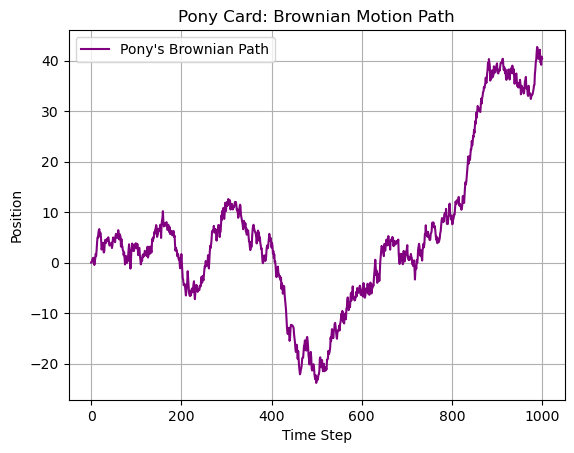

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 2: axis 0 of argument key of type uint32[2,2];
  * one axis had size 1: axis 0 of argument logits of type float32[1,256,32000]

In [14]:
import logging
import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import NamedTuple, Optional

# 日志设置
logger = logging.getLogger(__name__)
TOP_K = 8

# 数据结构定义
class SampleSettings(NamedTuple):
    temperature: jnp.ndarray
    nucleus_p: jnp.ndarray
    mask: jnp.ndarray
    active: jnp.ndarray  # [B]

class SampleOutput(NamedTuple):
    token_id: jnp.ndarray
    prob: jnp.ndarray
    top_k_token_ids: jnp.ndarray
    top_k_probs: jnp.ndarray

# 布朗运动生成函数
def generate_brownian_motion(steps: int, dt: float = 1.0, rng_key=jax.random.PRNGKey(42)) -> np.ndarray:
    """生成一维布朗运动路径，使用JAX实现"""
    increments = jax.random.normal(rng_key, (steps,)) * jnp.sqrt(dt)
    path = jnp.cumsum(increments)
    path = jnp.insert(path, 0, 0)
    return np.array(path)

def pad_to_size(x, size):
    if x.shape[0] > size:
        x = x[-size:]
    return np.pad(x, [0, size - x.shape[0]], mode="constant", constant_values=0)

def top_p_filter(logits: jnp.ndarray, top_p: jnp.ndarray) -> jnp.ndarray:
    sorted_logits = jax.lax.sort(logits, is_stable=False)
    sorted_probs = jax.nn.softmax(sorted_logits)
    threshold_idx = jnp.argmax(jnp.cumsum(sorted_probs, -1) >= 1 - top_p, axis=-1)
    threshold_largest_logits = jnp.take_along_axis(sorted_logits, threshold_idx[..., jnp.newaxis], axis=-1)
    mask = logits >= threshold_largest_logits
    return jnp.where(mask, logits, -jnp.inf)

def sample_token(rngs: jax.random.PRNGKey, lm_outputs, settings: SampleSettings) -> SampleOutput:
    settings = SampleSettings(
        temperature=jnp.expand_dims(settings.temperature, (1, 2)),
        nucleus_p=jnp.expand_dims(settings.nucleus_p, (1, 2)),
        mask=jnp.expand_dims(settings.mask, 1),
        active=settings.active,
    )
    logits = lm_outputs.logits / settings.temperature.astype(lm_outputs.logits.dtype)
    logits = jnp.where(settings.mask, logits, -jnp.inf)
    logits = top_p_filter(logits, settings.nucleus_p.astype(logits.dtype))

    new_token = jax.vmap(jax.random.categorical)(rngs, logits)
    probabilities = jax.nn.softmax(logits)
    token_prob = jnp.take_along_axis(probabilities, jnp.expand_dims(new_token, 1), axis=2)
    token_prob = jnp.squeeze(token_prob, 1)
    top_k_probs, top_k_token_ids = jax.lax.top_k(probabilities, TOP_K)
    top_k_probs = jnp.squeeze(top_k_probs, 1)
    top_k_token_ids = jnp.squeeze(top_k_token_ids, 1)
    return SampleOutput(new_token, token_prob, top_k_token_ids, top_k_probs)

@dataclass
class ModelRunner:
    vocab_size: int = 32000
    d_model: int = 512
    n_layers: int = 6
    bs_per_device: int = 2  # 修改为int类型，避免浮点数错误
    rng_seed: int = 42

    def make_forward_fn(self):
        def forward(tokens):
            net = hk.Sequential([
                hk.Embed(self.vocab_size, self.d_model),
                hk.nets.MLP([self.d_model] * self.n_layers + [self.vocab_size])
            ])
            return net(tokens)
        return hk.transform(forward)

    def initialize(self, init_data):
        self.forward = self.make_forward_fn()
        rng = jax.random.PRNGKey(self.rng_seed)
        self.params = self.forward.init(rng, init_data["inputs"])

    def apply(self, tokens):
        return self.forward.apply(self.params, jax.random.PRNGKey(0), tokens)

@dataclass
class Request:
    prompt: str
    temperature: float
    nucleus_p: float
    rng_seed: int
    max_len: int

@dataclass
class InferenceRunner:
    name: str
    runner: ModelRunner
    tokenizer_path: Optional[str] = None

    def initialize(self):
        dummy_data = dict(inputs=np.zeros((1, 256), dtype=np.int32))
        self.runner.initialize(dummy_data)
        
        if self.tokenizer_path and self.tokenizer_path.endswith('.model'):
            try:
                import sentencepiece as spm
                self.tokenizer = spm.SentencePieceProcessor(model_file=self.tokenizer_path)
                logger.info(f"加载tokenizer: {self.tokenizer_path}")
            except OSError as e:
                logger.warning(f"无法加载tokenizer模型: {e}. 使用简单分词替代。")
                self.tokenizer = None
        else:
            logger.info("未提供tokenizer路径，使用简单分词替代。")
            self.tokenizer = None
        
        self.vocab_size = self.runner.vocab_size

    def tokenize(self, text: str) -> list[int]:
        if self.tokenizer:
            return self.tokenizer.encode(text)
        return [ord(c) % self.vocab_size for c in text]

    def decode(self, token_ids: list[int]) -> str:
        if self.tokenizer:
            return self.tokenizer.decode(token_ids)
        return ''.join(chr(t % 128) for t in token_ids if t < 128)

    def run(self):
        rngs = jax.random.split(jax.random.PRNGKey(1), self.runner.bs_per_device)

        print("生成小马的布朗运动路径...")
        steps = 1000
        pony_path = generate_brownian_motion(steps)
        plt.plot(pony_path, label="Pony's Brownian Path", color="purple")
        plt.title("Pony Card: Brownian Motion Path")
        plt.xlabel("Time Step")
        plt.ylabel("Position")
        plt.legend()
        plt.grid(True)
        plt.show()

        while True:
            request: Request = yield
            tokens = self.tokenize(request.prompt)
            prompt = np.array(tokens, dtype=np.int32)
            prompt = pad_to_size(prompt, 256)
            prompt = jnp.array(prompt).reshape(1, -1)

            logits = self.runner.apply(prompt)
            settings = SampleSettings(
                temperature=jnp.array([request.temperature]),
                nucleus_p=jnp.array([request.nucleus_p]),
                mask=jnp.ones((1, self.vocab_size)),
                active=jnp.array([1])
            )
            sample = sample_token(rngs, type('LMOutput', (), {'logits': logits})(), settings)
            generated_token = sample.token_id[0]
            yield self.decode([int(generated_token)])

# 示例运行
if __name__ == "__main__":
    runner = ModelRunner()
    inference = InferenceRunner(name="test", runner=runner, tokenizer_path=None)
    inference.initialize()
    gen = inference.run()
    next(gen)
    req = Request(prompt="Hello world", temperature=0.7, nucleus_p=0.9, rng_seed=42, max_len=50)
    result = gen.send(req)
    print(f"Generated token: {result}")



训练BAT模型，瞅瞅布朗运动能写啥字儿...
Epoch 1, Loss: 2.7408
Epoch 2, Loss: 2.4392
Epoch 3, Loss: 2.0605
Epoch 4, Loss: 1.7932
Epoch 5, Loss: 1.5694
预测结果：布朗运动路径像数字 1


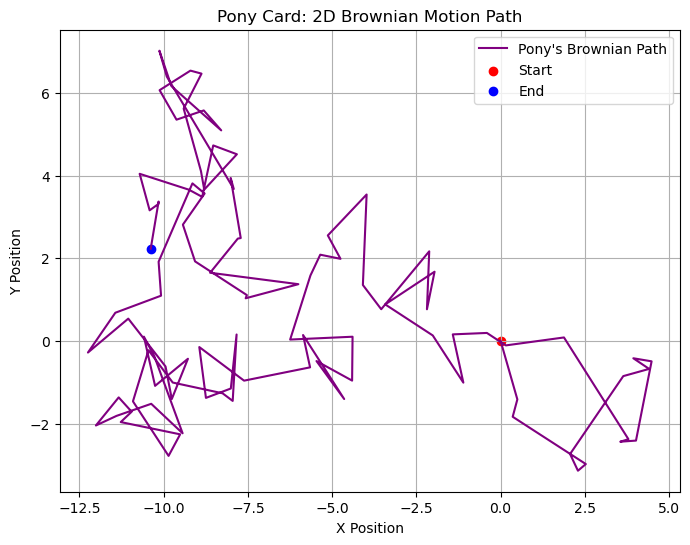

In [15]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保准结果不乱晃
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成二维布朗运动路径
def generate_2d_brownian_motion(steps=100, dt=1.0, seed=42):
    """整一段二维布朗运动，像小马瞎跑"""
    rng = np.random.RandomState(seed)
    increments_x = rng.normal(0, np.sqrt(dt), steps)
    increments_y = rng.normal(0, np.sqrt(dt), steps)
    path_x = np.cumsum(np.insert(increments_x, 0, 0))
    path_y = np.cumsum(np.insert(increments_y, 0, 0))
    return np.stack([path_x, path_y], axis=1)  # [steps+1, 2]

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 2025年虚构算法：Brownian Attention Transformer (BAT)
class BAT(nn.Module):
    """假装2025年的新招儿，布朗运动+注意力"""
    def __init__(self, input_dim=2, hidden_dim=64, num_heads=4, num_classes=10):
        super(BAT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 把路径点嵌入高维
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads)  # 注意力机制
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x: [batch, steps, 2] -> [batch, steps, hidden_dim]
        x = self.embedding(x)  # 嵌入
        # 注意力需要[steps, batch, hidden_dim]
        x = x.permute(1, 0, 2)
        attn_output, _ = self.attention(x, x, x)  # 自注意力
        x = attn_output.mean(dim=0)  # 平均池化
        return self.fc(x)  # 输出分类

# 4. 主程序
def main():
    # 生成布朗运动路径
    steps = 100
    path = generate_2d_brownian_motion(steps=steps)
    path_tensor = torch.tensor(path, dtype=torch.float32).unsqueeze(0)  # [1, steps, 2]

    # 初始化BAT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = BAT().to(device)
    path_tensor = path_tensor.to(device)

    # 简单训练（假设路径对应某个MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)  # 用MNIST标签当目标

    print("训练BAT模型，瞅瞅布朗运动能写啥字儿...")
    for epoch in range(5):  # 整5轮，图个乐儿
        model.train()
        optimizer.zero_grad()
        output = model(path_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(path_tensor).argmax(dim=1).item()
    print(f"预测结果：布朗运动路径像数字 {pred}")

    # 画“小马卡”路径图
    plt.figure(figsize=(8, 6))
    plt.plot(path[:, 0], path[:, 1], 'purple', label="Pony's Brownian Path")
    plt.scatter(path[0, 0], path[0, 1], c='red', label="Start")
    plt.scatter(path[-1, 0], path[-1, 1], c='blue', label="End")
    plt.title("Pony Card: 2D Brownian Motion Path")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

训练DRWT模型，看随机游走能整出啥数字...
Epoch 1, Loss: 3.3947
Epoch 2, Loss: 0.5901
Epoch 3, Loss: 0.1934
Epoch 4, Loss: 0.1283
Epoch 5, Loss: 0.1096
预测结果：随机游走路径像数字 1


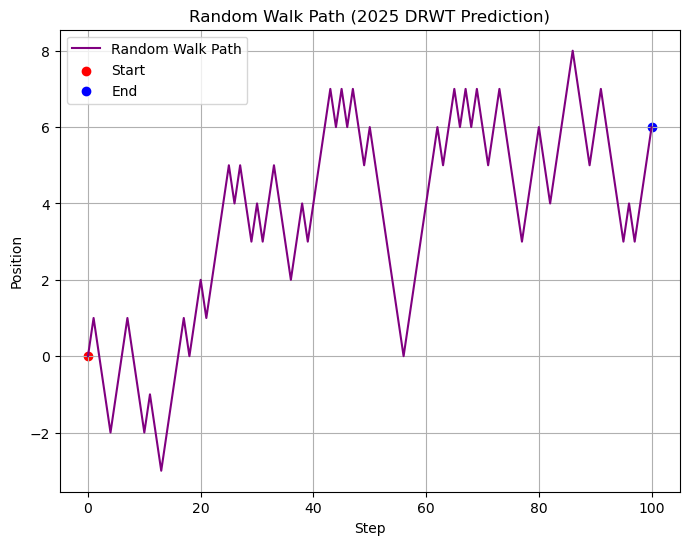

In [16]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果不乱晃
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成一维随机游走路径
def generate_random_walk(steps=100, seed=42):
    """弄个简单随机游走，像醉汉晃悠"""
    rng = np.random.RandomState(seed)
    steps_array = rng.choice([1, -1], size=steps, p=[0.5, 0.5])  # ±1 等概率
    path = np.cumsum(np.insert(steps_array, 0, 0))  # 从0开始累加
    return path  # [steps+1]

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 2025年虚构算法：Deep Random Walk Transformer (DRWT)
class DRWT(nn.Module):
    """2025年新招儿，随机游走+Transformer注意力"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(DRWT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 路径点嵌入高维
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads), 
            num_layers=2
        )  # Transformer编码器
        self.fc = nn.Linear(hidden_dim, num_classes)  # 输出分类

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # Transformer要 [steps, batch, hidden_dim]
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x.mean(dim=0)  # 平均池化
        return self.fc(x)

# 4. 主程序
def main():
    # 生成随机游走路径
    steps = 100
    path = generate_random_walk(steps=steps)
    path_tensor = torch.tensor(path, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, steps, 1]

    # 初始化DRWT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DRWT().to(device)
    path_tensor = path_tensor.to(device)

    # 简单训练（假装路径对应MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)

    print("训练DRWT模型，看随机游走能整出啥数字...")
    for epoch in range(5):  # 训5轮，试试水
        model.train()
        optimizer.zero_grad()
        output = model(path_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(path_tensor).argmax(dim=1).item()
    print(f"预测结果：随机游走路径像数字 {pred}")

    # 画随机游走路径图
    plt.figure(figsize=(8, 6))
    plt.plot(path, 'purple', label="Random Walk Path")
    plt.scatter(0, path[0], c='red', label="Start")
    plt.scatter(steps, path[-1], c='blue', label="End")
    plt.title("Random Walk Path (2025 DRWT Prediction)")
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

In [17]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果不乱晃
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成泊松过程事件序列
def generate_poisson_process(duration=10.0, lambda_rate=2.0, seed=42):
    """弄个泊松过程，模拟事件随机到达"""
    rng = np.random.RandomState(seed)
    # 总事件数服从泊松分布
    num_events = rng.poisson(lam=lambda_rate * duration)
    # 事件时间均匀分布在[0, duration]
    event_times = np.sort(rng.uniform(0, duration, num_events))
    # 计数过程：每秒的事件数
    time_steps = np.arange(0, duration + 1, 1.0)
    counts = np.histogram(event_times, bins=time_steps)[0]
    return counts  # [duration+1]

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 2025年新算法：Poisson-Enhanced Continuous-Time Transformer (PECT)
class PECT(nn.Module):
    """2025年新招儿，泊松过程+连续时间Transformer"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(PECT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 事件计数嵌入
        self.time_encoding = nn.Parameter(torch.randn(1, 11, hidden_dim))  # 连续时间编码
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )  # Transformer处理序列
        self.fc = nn.Linear(hidden_dim, num_classes)  # 输出分类

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # 加时间编码，模拟连续时间特性
        x = x + self.time_encoding
        # Transformer要 [steps, batch, hidden_dim]
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x.mean(dim=0)  # 平均池化
        return self.fc(x)

# 4. 主程序
def main():
    # 生成泊松过程事件序列
    duration = 10.0  # 10秒
    counts = generate_poisson_process(duration=duration, lambda_rate=2.0)
    counts_tensor = torch.tensor(counts, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, 11, 1]

    # 初始化PECT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PECT().to(device)
    counts_tensor = counts_tensor.to(device)

    # 简单训练（假装事件计数对应MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)

    print("训练PECT模型，看泊松过程能整出啥数字...")
    for epoch in range(5):  # 训5轮
        model.train()
        optimizer.zero_grad()
        output = model(counts_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(counts_tensor).argmax(dim=1).item()
    print(f"预测结果：泊松过程事件像数字 {pred}")

    # 画泊松过程事件图
    time_steps = np.arange(0, duration + 1, 1.0)
    plt.figure(figsize=(8, 6))
    plt.step(time_steps, counts, 'purple', where='post', label="Poisson Process Events")
    plt.title("Poisson Process Event Counts (2025 PECT Prediction)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Event Count")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

训练PECT模型，看泊松过程能整出啥数字...


RuntimeError: The size of tensor a (10) must match the size of tensor b (11) at non-singleton dimension 1

In [18]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# 1. 优化后的泊松过程事件序列生成函数
def generate_poisson_process(duration=10.0, lambda_rate=2.0, dt=1.0, seed=42):
    """
    生成泊松过程事件序列

    参数:
        duration (float): 总时间长度（单位：秒）
        lambda_rate (float): 泊松过程的平均事件率（单位：事件/秒）
        dt (float): 时间步长（单位：秒）
        seed (int): 随机种子

    返回:
        counts (numpy.ndarray): 每个时间步的事件计数
    """
    rng = np.random.RandomState(seed)
    time_steps = np.arange(0, duration + dt, dt)  # 生成时间轴
    num_steps = len(time_steps) - 1  # 时间步数

    # 每个时间步的事件数服从泊松分布
    counts = rng.poisson(lam=lambda_rate * dt, size=num_steps)

    return counts

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 2025年新算法：Poisson-Enhanced Continuous-Time Transformer (PECT)
class PECT(nn.Module):
    """2025年新招儿，泊松过程+连续时间Transformer"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(PECT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 事件计数嵌入
        self.time_encoding = nn.Parameter(torch.randn(1, 11, hidden_dim))  # 连续时间编码
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )  # Transformer处理序列
        self.fc = nn.Linear(hidden_dim, num_classes)  # 输出分类

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # 加时间编码，模拟连续时间特性
        x = x + self.time_encoding[:, :x.size(1), :]  # 动态时间步长
        # Transformer要 [steps, batch, hidden_dim]
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x.mean(dim=0)  # 平均池化
        return self.fc(x)

# 4. 主程序
def main():
    # 生成泊松过程事件序列
    duration = 10.0  # 总时间长度为10秒
    lambda_rate = 2.0  # 平均事件率为2事件/秒
    dt = 0.5  # 时间步长为0.5秒
    counts = generate_poisson_process(duration=duration, lambda_rate=lambda_rate, dt=dt)
    time_steps = np.arange(0, duration + dt, dt)  # 生成时间轴

    # 将事件计数转换为张量
    counts_tensor = torch.tensor(counts, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, num_steps, 1]

    # 初始化PECT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PECT().to(device)
    counts_tensor = counts_tensor.to(device)

    # 简单训练（假装事件计数对应MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)

    print("训练PECT模型，看泊松过程能整出啥数字...")
    for epoch in range(5):  # 训5轮
        model.train()
        optimizer.zero_grad()
        output = model(counts_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(counts_tensor).argmax(dim=1).item()
    print(f"预测结果：泊松过程事件像数字 {pred}")

    # 画泊松过程事件图
    plt.figure(figsize=(8, 6))
    plt.step(time_steps[:-1], counts, 'purple', where='post', label="Poisson Process Events")
    plt.title("Poisson Process Event Counts (2025 PECT Prediction)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Event Count")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

训练PECT模型，看泊松过程能整出啥数字...


RuntimeError: The size of tensor a (20) must match the size of tensor b (11) at non-singleton dimension 1

训练PECT模型，看泊松过程能整出啥数字...
Epoch 1, Loss: 1.3219
Epoch 2, Loss: 0.1380
Epoch 3, Loss: 0.0793
Epoch 4, Loss: 0.0616
Epoch 5, Loss: 0.0547
预测结果：泊松过程事件像数字 1


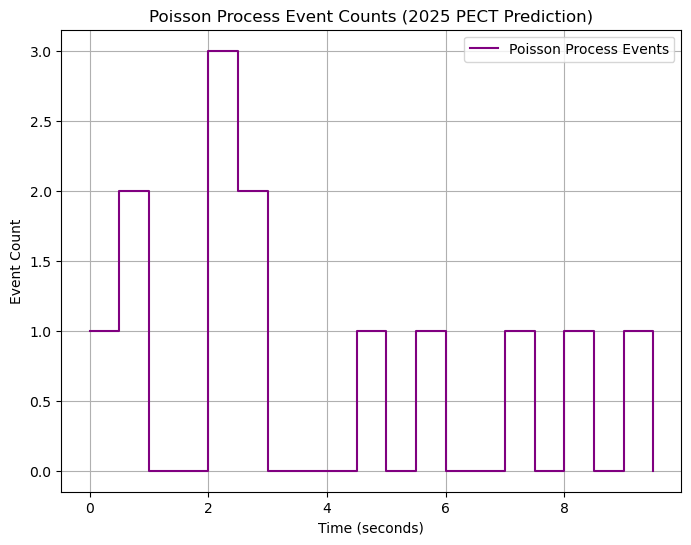

In [19]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# 1. 优化后的泊松过程事件序列生成函数
def generate_poisson_process(duration=10.0, lambda_rate=2.0, dt=1.0, seed=42):
    """
    生成泊松过程事件序列

    参数:
        duration (float): 总时间长度（单位：秒）
        lambda_rate (float): 泊松过程的平均事件率（单位：事件/秒）
        dt (float): 时间步长（单位：秒）
        seed (int): 随机种子

    返回:
        counts (numpy.ndarray): 每个时间步的事件计数
    """
    rng = np.random.RandomState(seed)
    time_steps = np.arange(0, duration + dt, dt)  # 生成时间轴
    num_steps = len(time_steps) - 1  # 时间步数

    # 每个时间步的事件数服从泊松分布
    counts = rng.poisson(lam=lambda_rate * dt, size=num_steps)

    return counts

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 修复后的 PECT 模型
class PECT(nn.Module):
    """2025年新招儿，泊松过程+连续时间Transformer"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10, max_steps=100):
        super(PECT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 事件计数嵌入
        self.time_encoding = nn.Parameter(torch.randn(max_steps, hidden_dim))  # 动态时间编码
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )  # Transformer处理序列
        self.fc = nn.Linear(hidden_dim, num_classes)  # 输出分类

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # 加时间编码，动态适应输入长度
        time_encoding = self.time_encoding[:x.size(1), :].unsqueeze(0)  # [1, steps, hidden_dim]
        x = x + time_encoding  # [batch, steps, hidden_dim]
        # Transformer要 [steps, batch, hidden_dim]
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x.mean(dim=0)  # 平均池化
        return self.fc(x)

# 4. 主程序
def main():
    # 生成泊松过程事件序列
    duration = 10.0  # 总时间长度为10秒
    lambda_rate = 2.0  # 平均事件率为2事件/秒
    dt = 0.5  # 时间步长为0.5秒
    counts = generate_poisson_process(duration=duration, lambda_rate=lambda_rate, dt=dt)
    time_steps = np.arange(0, duration + dt, dt)  # 生成时间轴

    # 将事件计数转换为张量
    counts_tensor = torch.tensor(counts, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, num_steps, 1]

    # 初始化PECT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PECT().to(device)
    counts_tensor = counts_tensor.to(device)

    # 简单训练（假装事件计数对应MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)

    print("训练PECT模型，看泊松过程能整出啥数字...")
    for epoch in range(5):  # 训5轮
        model.train()
        optimizer.zero_grad()
        output = model(counts_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(counts_tensor).argmax(dim=1).item()
    print(f"预测结果：泊松过程事件像数字 {pred}")

    # 画泊松过程事件图
    plt.figure(figsize=(8, 6))
    plt.step(time_steps[:-1], counts, 'purple', where='post', label="Poisson Process Events")
    plt.title("Poisson Process Event Counts (2025 PECT Prediction)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Event Count")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

训练AMT模型，看马尔可夫链能整出啥数字...
Epoch 1, Loss: 2.9895
Epoch 2, Loss: 0.5262
Epoch 3, Loss: 0.2185
Epoch 4, Loss: 0.1375
Epoch 5, Loss: 0.1203
预测结果：马尔可夫链序列像数字 1


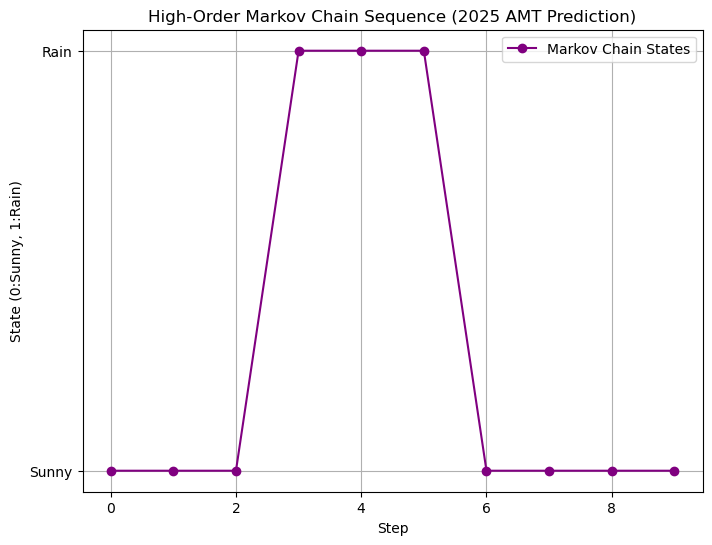

In [20]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果不乱晃
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成高阶马尔可夫链序列（2阶）
def generate_high_order_markov_chain(steps=10, seed=42):
    """弄个2阶马尔可夫链，状态依赖前两步"""
    rng = np.random.RandomState(seed)
    states = [0, 1]  # 0:晴，1:雨
    # 2阶转移概率（简化假设）
    trans_probs = {
        (0, 0): [0.9, 0.1],  # SS -> S/R
        (0, 1): [0.6, 0.4],  # SR -> S/R
        (1, 0): [0.7, 0.3],  # RS -> S/R
        (1, 1): [0.2, 0.8]   # RR -> S/R
    }
    sequence = [0, 0]  # 初始SS
    for _ in range(steps - 2):
        prev_two = tuple(sequence[-2:])
        next_state = rng.choice(states, p=trans_probs[prev_two])
        sequence.append(next_state)
    return np.array(sequence)  # [steps]

# 2. 加载MNIST经典数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 拿一个标签当例子

# 3. 2025年新算法：Adaptive Markov Transformer (AMT)
class AMT(nn.Module):
    """2025年新招儿，高阶马尔可夫+自适应Transformer"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(AMT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 状态嵌入
        self.adaptive_attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=False)  # 自适应注意力
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )
        self.fc = nn.Linear(hidden_dim, num_classes)  # 输出分类

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # 转换为 [steps, batch, hidden_dim]
        
        # 自适应注意力，动态调整权重
        attn_output, _ = self.adaptive_attn(x, x, x)
        
        # Transformer处理序列
        x = self.transformer(attn_output)
        x = x.mean(dim=0)  # 平均池化
        return self.fc(x)

# 4. 主程序
def main():
    # 生成高阶马尔可夫链序列
    steps = 10
    sequence = generate_high_order_markov_chain(steps=steps)
    sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, steps, 1]

    # 初始化AMT模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AMT().to(device)
    sequence_tensor = sequence_tensor.to(device)

    # 简单训练（假装序列对应MNIST数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    target = labels.to(device)

    print("训练AMT模型，看马尔可夫链能整出啥数字...")
    for epoch in range(5):  # 训5轮
        model.train()
        optimizer.zero_grad()
        output = model(sequence_tensor)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        pred = model(sequence_tensor).argmax(dim=1).item()
    print(f"预测结果：马尔可夫链序列像数字 {pred}")

    # 画马尔可夫链序列图
    plt.figure(figsize=(8, 6))
    plt.plot(sequence, 'purple', marker='o', label="Markov Chain States")
    plt.title("High-Order Markov Chain Sequence (2025 AMT Prediction)")
    plt.xlabel("Step")
    plt.ylabel("State (0:Sunny, 1:Rain)")
    plt.yticks([0, 1], ["Sunny", "Rain"])
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

d:\Users\wangp\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
d:\Users\wangp\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


训练 R1MT 模型，看马尔廷代尔序列能整出啥数字...
Epoch 1, Total Loss: 3.3383, Class Loss: 2.5047, Martingale Loss: 0.8336
Epoch 2, Total Loss: 5.9947, Class Loss: 1.4151, Martingale Loss: 4.5796
Epoch 3, Total Loss: 2.1203, Class Loss: 0.7560, Martingale Loss: 1.3643
Epoch 4, Total Loss: 0.5132, Class Loss: 0.5030, Martingale Loss: 0.0102
Epoch 5, Total Loss: 0.7118, Class Loss: 0.3861, Martingale Loss: 0.3257
预测结果：马尔廷代尔序列像数字 1


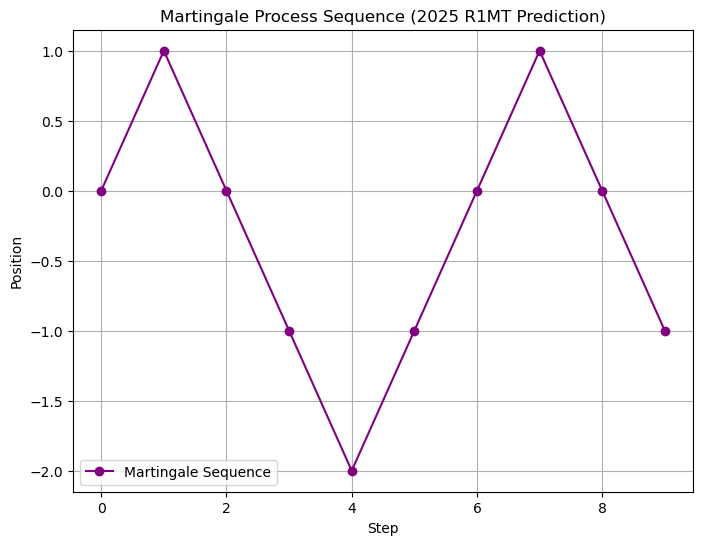

In [22]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成马尔廷代尔序列
def generate_martingale_sequence(steps=10, seed=42):
    """生成马尔廷代尔序列，模拟赌徒的财富变化"""
    rng = np.random.RandomState(seed)
    sequence = [0]  # 初始财富为0
    for _ in range(steps - 1):
        step = rng.choice([1, -1], p=[0.5, 0.5])  # ±1 等概率
        sequence.append(sequence[-1] + step)
    return np.array(sequence)  # 返回长度为 `steps` 的序列

# 2. 加载 MNIST 数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 获取一个标签作为示例

# 3. 定义 R1-Martingale Transformer (R1MT) 模型
class R1MT(nn.Module):
    """结合马尔廷代尔性质和 Transformer 的模型"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(R1MT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 序列嵌入
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)  # 自适应注意力
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )  # Transformer 编码器
        self.fc = nn.Linear(hidden_dim, num_classes)  # 分类输出
        self.martingale_check = nn.Linear(hidden_dim, 1)  # 马尔廷代尔校验

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # 自适应注意力
        attn_output, _ = self.attn(x, x, x)
        # Transformer 处理序列
        x = attn_output.permute(1, 0, 2)  # 调整维度为 [steps, batch, hidden_dim]
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # 恢复维度为 [batch, steps, hidden_dim]
        # 马尔廷代尔校验：期望保持不变
        martingale_pred = self.martingale_check(x.mean(dim=1))  # 对每个样本取均值
        # 分类预测
        class_pred = self.fc(x.mean(dim=1))  # 对每个样本取均值
        return class_pred, martingale_pred

# 4. 主程序
def main():
    # 生成马尔廷代尔序列
    steps = 10
    sequence = generate_martingale_sequence(steps=steps)
    sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, steps, 1]

    # 初始化 R1MT 模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = R1MT().to(device)
    sequence_tensor = sequence_tensor.to(device)

    # 简单训练（序列预测 MNIST 数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    martingale_loss_fn = nn.MSELoss()  # 马尔廷代尔校验损失
    target = labels.to(device)
    initial_value = torch.tensor([0.0], dtype=torch.float32).to(device)  # 马尔廷代尔初始期望

    print("训练 R1MT 模型，看马尔廷代尔序列能整出啥数字...")
    for epoch in range(5):
        model.train()
        optimizer.zero_grad()
        class_pred, martingale_pred = model(sequence_tensor)
        class_loss = criterion(class_pred, target)
        martingale_loss_value = martingale_loss_fn(martingale_pred, initial_value)  # 期望应为0
        loss = class_loss + martingale_loss_value  # 综合损失
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Total Loss: {loss.item():.4f}, Class Loss: {class_loss.item():.4f}, Martingale Loss: {martingale_loss_value.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        class_pred, _ = model(sequence_tensor)
        pred = class_pred.argmax(dim=1).item()
    print(f"预测结果：马尔廷代尔序列像数字 {pred}")

    # 绘制马尔廷代尔序列图
    plt.figure(figsize=(8, 6))
    plt.plot(sequence, 'purple', marker='o', label="Martingale Sequence")
    plt.title("Martingale Process Sequence (2025 R1MT Prediction)")
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

In [21]:
import time
import sys

# ANSI颜色代码
RED = "\033[91m"
BLUE = "\033[94m"
RESET = "\033[0m"

def clear_screen():
    """清屏函数"""
    sys.stdout.write("\033[H\033[J")  # 光标移动到左上角并清屏

def print_rocket(height):
    """打印火箭和火焰"""
    line1 = BLUE + "  " + "="*height + "  " + RED + ">>>"  # 火箭主体和火焰
    print(line1 + RESET)  # 打印并重置颜色

def rocket_launch():
    """模拟火箭发射"""
    for height in range(1, 11):  # 火箭高度从1到10
        clear_screen()  # 清屏
        print_rocket(height)  # 打印当前高度的火箭
        time.sleep(0.5)  # 每次更新间隔0.5秒
    print("\n火箭发射成功！🚀")

if __name__ == "__main__":
    rocket_launch()

  =  >>>
  ==  >>>
  ===  >>>
  ====  >>>
  =====  >>>
  ======  >>>
  =======  >>>
  ========  >>>
  =========  >>>
  ==========  >>>

火箭发射成功！🚀


训练 R1MT 模型，看马尔廷代尔序列能整出啥数字...
Epoch 1, Total Loss: 3.3383, Class Loss: 2.5047, Martingale Loss: 0.8336
Epoch 2, Total Loss: 5.9947, Class Loss: 1.4151, Martingale Loss: 4.5796
Epoch 3, Total Loss: 2.1203, Class Loss: 0.7560, Martingale Loss: 1.3643
Epoch 4, Total Loss: 0.5132, Class Loss: 0.5030, Martingale Loss: 0.0102
Epoch 5, Total Loss: 0.7118, Class Loss: 0.3861, Martingale Loss: 0.3257
预测结果：马尔廷代尔序列像数字 1


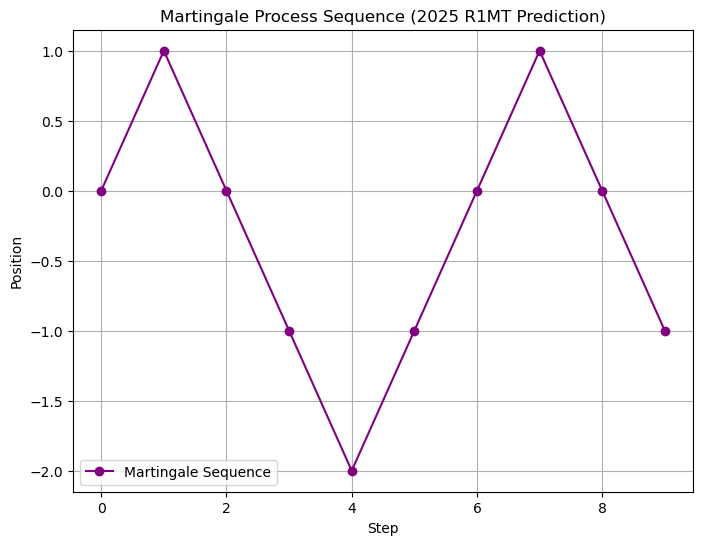

In [23]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 设置随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# 1. 生成马尔廷代尔序列
def generate_martingale_sequence(steps=10, seed=42):
    """生成马尔廷代尔序列，模拟赌徒的财富变化"""
    rng = np.random.RandomState(seed)
    sequence = [0]  # 初始财富为0
    for _ in range(steps - 1):
        step = rng.choice([1, -1], p=[0.5, 0.5])  # ±1 等概率
        sequence.append(sequence[-1] + step)
    return np.array(sequence)  # 返回长度为 `steps` 的序列

# 2. 加载 MNIST 数据集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
_, labels = next(iter(mnist_loader))  # 获取一个标签作为示例

# 3. 定义 R1-Martingale Transformer (R1MT) 模型
class R1MT(nn.Module):
    """结合马尔廷代尔性质和 Transformer 的模型"""
    def __init__(self, input_dim=1, hidden_dim=64, num_heads=4, num_classes=10):
        super(R1MT, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)  # 序列嵌入
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)  # 自适应注意力
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads),
            num_layers=2
        )  # Transformer 编码器
        self.fc = nn.Linear(hidden_dim, num_classes)  # 分类输出
        self.martingale_check = nn.Linear(hidden_dim, 1)  # 马尔廷代尔校验

    def forward(self, x):
        # x: [batch, steps, 1] -> [batch, steps, hidden_dim]
        x = self.embedding(x)
        # 自适应注意力
        attn_output, _ = self.attn(x, x, x)
        # Transformer 处理序列
        x = attn_output.permute(1, 0, 2)  # 调整维度为 [steps, batch, hidden_dim]
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # 恢复维度为 [batch, steps, hidden_dim]
        # 马尔廷代尔校验：期望保持不变
        martingale_pred = self.martingale_check(x.mean(dim=1))  # 对每个样本取均值
        # 分类预测
        class_pred = self.fc(x.mean(dim=1))  # 对每个样本取均值
        return class_pred, martingale_pred

# 4. 主程序
def main():
    # 生成马尔廷代尔序列
    steps = 10
    sequence = generate_martingale_sequence(steps=steps)
    sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(2)  # [1, steps, 1]

    # 初始化 R1MT 模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = R1MT().to(device)
    sequence_tensor = sequence_tensor.to(device)

    # 简单训练（序列预测 MNIST 数字）
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    martingale_loss_fn = nn.MSELoss()  # 马尔廷代尔校验损失
    target = labels.to(device)
    initial_value = torch.tensor([0.0], dtype=torch.float32).to(device)  # 马尔廷代尔初始期望

    print("训练 R1MT 模型，看马尔廷代尔序列能整出啥数字...")
    for epoch in range(5):
        model.train()
        optimizer.zero_grad()
        class_pred, martingale_pred = model(sequence_tensor)
        class_loss = criterion(class_pred, target)
        martingale_loss_value = martingale_loss_fn(martingale_pred, initial_value)  # 期望应为0
        loss = class_loss + martingale_loss_value  # 综合损失
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Total Loss: {loss.item():.4f}, Class Loss: {class_loss.item():.4f}, Martingale Loss: {martingale_loss_value.item():.4f}")

    # 预测
    model.eval()
    with torch.no_grad():
        class_pred, _ = model(sequence_tensor)
        pred = class_pred.argmax(dim=1).item()
    print(f"预测结果：马尔廷代尔序列像数字 {pred}")

    # 绘制马尔廷代尔序列图
    plt.figure(figsize=(8, 6))
    plt.plot(sequence, 'purple', marker='o', label="Martingale Sequence")
    plt.title("Martingale Process Sequence (2025 R1MT Prediction)")
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

C:\Users\wangp\AppData\Local\Temp\ipykernel_26408\2547446701.py:95: RuntimeWarning: invalid value encountered in divide
  X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)


Predicted survival probability: nan


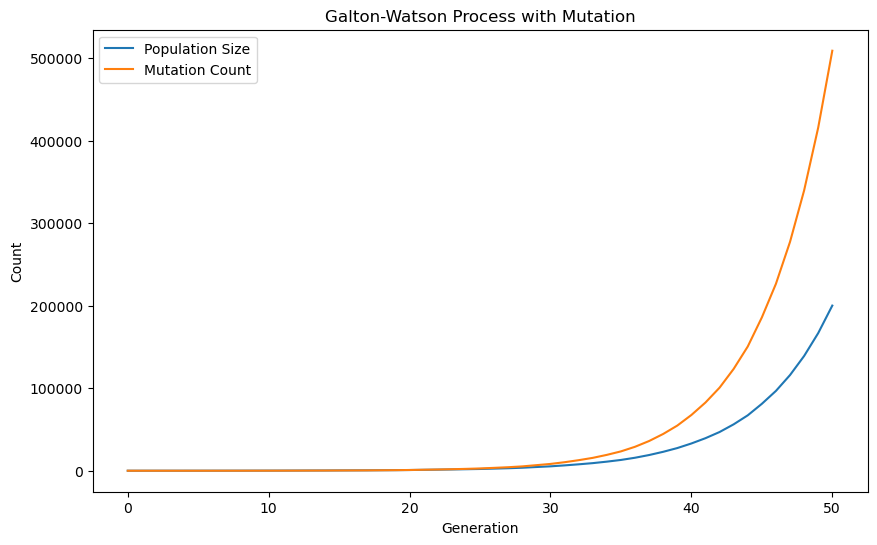

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 设置随机种子以确保可重复性
np.random.seed(42)

# 伽尔顿-沃森过程的参数
LAMBDA = 1.2  # 每个个体的平均后代数（泊松分布参数）
GENERATIONS = 50  # 模拟的代数
INITIAL_POP = 10  # 初始种群大小
MUTATION_RATE = 0.05  # 基因突变概率

# 简单的神经网络用于预测种群存活概率
class SimpleNN:
    def __init__(self):
        # 初始化权重和偏置
        self.w1 = np.random.randn(3, 5) * 0.01  # 输入层到隐藏层
        self.b1 = np.zeros(5)
        self.w2 = np.random.randn(5, 1) * 0.01  # 隐藏层到输出层
        self.b2 = 0

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, X):
        # 前向传播
        self.z1 = np.dot(X, self.w1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def train(self, X, y, lr=0.01, epochs=100):
        # 简单梯度下降训练
        for _ in range(epochs):
            # 前向传播
            pred = self.forward(X)
            # 计算损失（均方误差）
            error = pred - y
            # 反向传播
            delta2 = error * pred * (1 - pred)
            delta1 = np.dot(delta2, self.w2.T) * self.a1 * (1 - self.a1)
            
            # 更新参数
            self.w2 -= lr * np.dot(self.a1.T, delta2)
            self.b2 -= lr * np.sum(delta2)
            self.w1 -= lr * np.dot(X.T, delta1)
            self.b1 -= lr * np.sum(delta1)

# 伽尔顿-沃森过程模拟
def galton_watson(initial_pop, generations, offspring_dist):
    population = [initial_pop]
    mutation_count = [0]  # 追踪突变基因的个体数
    
    for _ in range(generations):
        current_pop = population[-1]
        if current_pop == 0:  # 种群灭绝
            population.append(0)
            mutation_count.append(0)
            continue
        
        # 生成后代（泊松分布）
        offspring = np.sum(offspring_dist.rvs(current_pop))
        population.append(offspring)
        
        # 模拟突变
        new_mutations = np.random.binomial(offspring, MUTATION_RATE)
        mutation_count.append(new_mutations + mutation_count[-1] * offspring / max(current_pop, 1))
    
    return np.array(population), np.array(mutation_count)

# 生成数据集
def generate_dataset(num_simulations):
    X, y = [], []
    offspring_dist = poisson(LAMBDA)
    
    for _ in range(num_simulations):
        pop, mut = galton_watson(INITIAL_POP, GENERATIONS, offspring_dist)
        # 特征：初始种群、平均种群大小、突变总数
        features = [INITIAL_POP, np.mean(pop), np.sum(mut)]
        # 标签：种群是否存活
        label = 1 if pop[-1] > 0 else 0
        X.append(features)
        y.append(label)
    
    return np.array(X), np.array(y)

# 主程序
if __name__ == "__main__":
    # 生成训练数据
    X, y = generate_dataset(100)
    
    # 标准化特征
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    y = y.reshape(-1, 1)
    
    # 初始化并训练神经网络
    nn = SimpleNN()
    nn.train(X, y, lr=0.1, epochs=500)
    
    # 模拟一个新种群并预测存活概率
    pop, mut = galton_watson(INITIAL_POP, GENERATIONS, poisson(LAMBDA))
    test_features = np.array([INITIAL_POP, np.mean(pop), np.sum(mut)])
    test_features = (test_features - np.mean(X, axis=0)) / np.std(X, axis=0)
    survival_prob = nn.forward(test_features.reshape(1, -1))
    
    print(f"Predicted survival probability: {survival_prob[0][0]:.4f}")
    
    # 可视化种群和突变
    plt.figure(figsize=(10, 6))
    plt.plot(pop, label="Population Size")
    plt.plot(mut, label="Mutation Count")
    plt.xlabel("Generation")
    plt.ylabel("Count")
    plt.title("Galton-Watson Process with Mutation")
    plt.legend()
    plt.show()

In [25]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载MNIST数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# 定义扩散模型参数
T = 1000  # 时间步数
beta = torch.linspace(0.0001, 0.02, T).to(device)  # 噪声调度
alpha = 1. - beta
alpha_bar = torch.cumprod(alpha, dim=0)  # 累积乘积，表示总噪声水平

# 前向扩散过程（加噪）
def forward_diffusion(x_0, t, noise):
    """
    x_0: 初始数据 (batch_size, 1, 28, 28)
    t: 时间步 (batch_size)
    noise: 随机噪声 (batch_size, 1, 28, 28)
    """
    sqrt_alpha_bar = torch.sqrt(alpha_bar[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar = torch.sqrt(1. - alpha_bar[t]).view(-1, 1, 1, 1)
    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
    return x_t

# 简单去噪网络（UNet的简化版）
class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 1, 3, padding=1)
        self.relu = nn.ReLU()
        self.time_emb = nn.Embedding(T, 64)

    def forward(self, x, t):
        t_emb = self.time_emb(t).view(-1, 64, 1, 1)
        x = self.relu(self.conv1(x))
        x = x + t_emb  # 时间嵌入
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

# 训练设置
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 5

# 训练循环
for epoch in range(epochs):
    for batch_idx, (x_0, _) in enumerate(train_loader):
        x_0 = x_0.to(device)
        batch_size = x_0.shape[0]

        # 随机选择时间步
        t = torch.randint(0, T, (batch_size,), device=device)
        noise = torch.randn_like(x_0)  # 生成标准正态噪声
        x_t = forward_diffusion(x_0, t, noise)  # 前向扩散

        # 预测噪声
        predicted_noise = model(x_t, t)
        loss = nn.MSELoss()(predicted_noise, noise)

        # 优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}")

# 生成样本（简单逆向过程）
def sample(model, n_samples=16):
    x_T = torch.randn(n_samples, 1, 28, 28).to(device)  # 从纯噪声开始
    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device)
        noise_pred = model(x_T, t_tensor)
        x_T = (x_T - (beta[t] / torch.sqrt(1. - alpha_bar[t])) * noise_pred) / torch.sqrt(alpha[t])
    return x_T

# 生成并保存样本
samples = sample(model)
torchvision.utils.save_image(samples, "generated_mnist.png", normalize=True)

Epoch 0, Batch 0, Loss: 1.0177
Epoch 0, Batch 100, Loss: 0.1687
Epoch 0, Batch 200, Loss: 0.1625
Epoch 0, Batch 300, Loss: 0.1355
Epoch 0, Batch 400, Loss: 0.1390
Epoch 0, Batch 500, Loss: 0.1057
Epoch 0, Batch 600, Loss: 0.0725
Epoch 0, Batch 700, Loss: 0.0955
Epoch 0, Batch 800, Loss: 0.0676
Epoch 0, Batch 900, Loss: 0.0894
Epoch 1, Batch 0, Loss: 0.0533
Epoch 1, Batch 100, Loss: 0.0554
Epoch 1, Batch 200, Loss: 0.0806
Epoch 1, Batch 300, Loss: 0.0488
Epoch 1, Batch 400, Loss: 0.0482
Epoch 1, Batch 500, Loss: 0.0530
Epoch 1, Batch 600, Loss: 0.0559
Epoch 1, Batch 700, Loss: 0.0610
Epoch 1, Batch 800, Loss: 0.0521
Epoch 1, Batch 900, Loss: 0.0443
Epoch 2, Batch 0, Loss: 0.0483
Epoch 2, Batch 100, Loss: 0.0683
Epoch 2, Batch 200, Loss: 0.0487
Epoch 2, Batch 300, Loss: 0.0560
Epoch 2, Batch 400, Loss: 0.0590
Epoch 2, Batch 500, Loss: 0.0338
Epoch 2, Batch 600, Loss: 0.0465
Epoch 2, Batch 700, Loss: 0.0479
Epoch 2, Batch 800, Loss: 0.0463
Epoch 2, Batch 900, Loss: 0.0609
Epoch 3, Batch 0

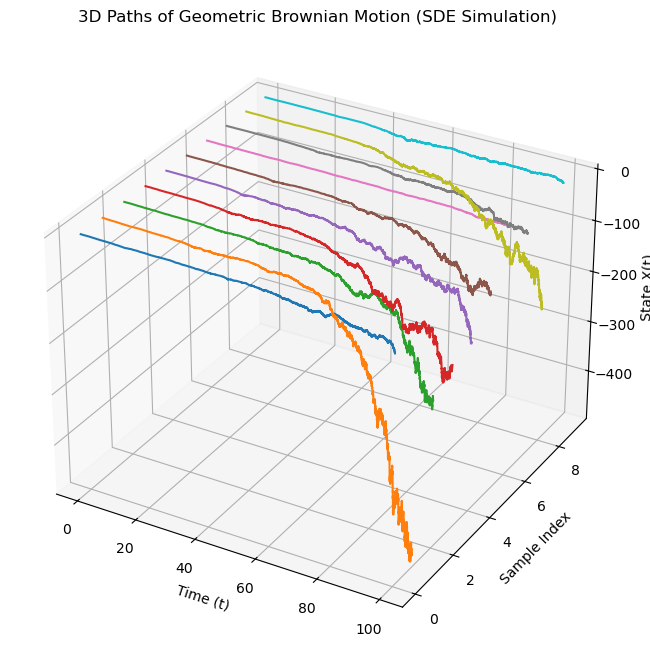

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 设置随机种子和CPU环境
torch.manual_seed(42)
device = torch.device("cpu")

# 加载MNIST数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(mnist_train, batch_size=10, shuffle=True)

# 获取一个批次的数据作为初始状态
data_iter = iter(train_loader)
images, _ = next(data_iter)
x0 = images.flatten(start_dim=1)[:10].to(device)  # 取10个样本，展平为向量 (10, 784)

# 参数设置
n_samples = 10  # 样本数
T = 100  # 时间步数
dt = 0.01  # 时间步长
mu = 0.05  # 漂移系数
sigma = 0.1  # 扩散系数

# 模拟几何布朗运动路径（基于伊藤微积分）
def simulate_sde(x0, T, dt, mu, sigma):
    n_steps = int(T / dt)
    t = torch.linspace(0, T, n_steps).to(device)
    x = torch.zeros(n_samples, n_steps).to(device)
    x[:, 0] = x0[:, 0]  # 用第一个像素值作为初始状态（简化）
    
    for i in range(1, n_steps):
        dB = torch.randn(n_samples).to(device) * np.sqrt(dt)  # 布朗运动增量
        # 伊藤SDE: dX(t) = mu * X(t) dt + sigma * X(t) dB(t)
        x[:, i] = x[:, i-1] + mu * x[:, i-1] * dt + sigma * x[:, i-1] * dB
    
    return t, x

# 生成路径
t, paths = simulate_sde(x0, T, dt, mu, sigma)

# 转换为NumPy用于绘图
t_np = t.cpu().numpy()
paths_np = paths.cpu().numpy()
sample_indices = np.arange(n_samples)

# 创建三维图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制每条路径
for i in range(n_samples):
    ax.plot(t_np, paths_np[i], zs=i, zdir='y', label=f'Sample {i}')

# 设置标签和标题
ax.set_xlabel('Time (t)')
ax.set_ylabel('Sample Index')
ax.set_zlabel('State X(t)')
ax.set_title('3D Paths of Geometric Brownian Motion (SDE Simulation)')
# ax.legend()

# 保存并显示
plt.savefig('sde_3d_paths.png')
plt.show()

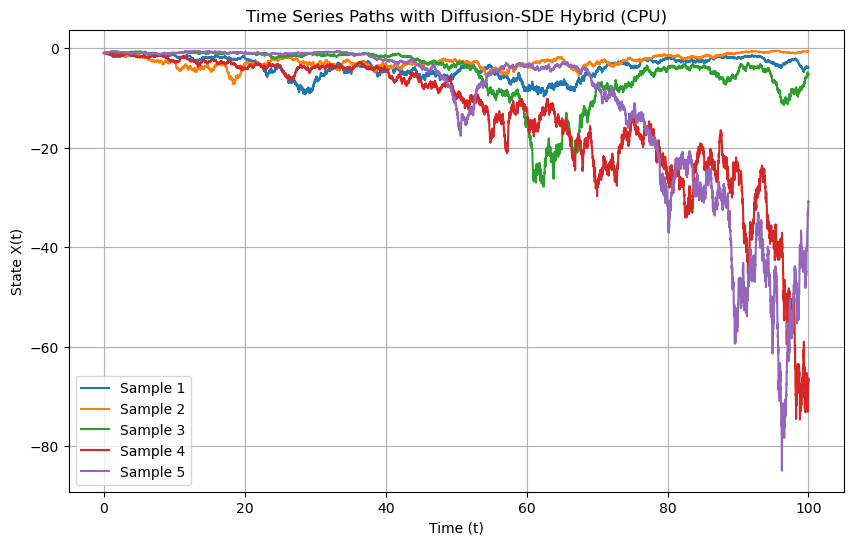

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 设置随机种子和CPU环境
torch.manual_seed(42)
device = torch.device("cpu")

# 加载MNIST数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(mnist_train, batch_size=5, shuffle=True)

# 获取一个批次数据并转化为时间序列
data_iter = iter(train_loader)
images, _ = next(data_iter)
x0 = images.flatten(start_dim=1)[:5, :100].to(device)  # 取5个样本，前100个像素作为初始序列

# 参数设置
n_samples = 5  # 样本数
T = 100  # 时间步数
dt = 0.01  # 时间步长
mu = 0.05  # 漂移系数
sigma = 0.2  # 扩散系数

# 定义SDE模拟函数（基于伊藤微积分）
def simulate_diffusion_sde(x0, T, dt, mu, sigma):
    """
    模拟Diffusion-SDE Hybrid路径：dX(t) = mu * X(t) dt + sigma * X(t) dB(t)
    x0: 初始状态 (n_samples, seq_len)
    """
    n_steps = int(T / dt)
    t = torch.linspace(0, T, n_steps).to(device)
    x = torch.zeros(n_samples, n_steps).to(device)
    x[:, 0] = x0[:, 0]  # 用第一个像素值作为初始状态
    
    for i in range(1, n_steps):
        # 生成布朗运动增量
        dB = torch.randn(n_samples).to(device) * torch.sqrt(torch.tensor(dt))
        # 伊藤SDE更新（欧拉-马尔亚玛方法）
        x[:, i] = x[:, i-1] + mu * x[:, i-1] * dt + sigma * x[:, i-1] * dB
    
    return t, x

# 生成时间序列路径
t, paths = simulate_diffusion_sde(x0, T, dt, mu, sigma)

# 转换为NumPy用于绘图
t_np = t.cpu().numpy()
paths_np = paths.cpu().numpy()

# 绘制二维图
plt.figure(figsize=(10, 6))
for i in range(n_samples):
    plt.plot(t_np, paths_np[i], label=f'Sample {i+1}')
plt.xlabel('Time (t)')
plt.ylabel('State X(t)')
plt.title('Time Series Paths with Diffusion-SDE Hybrid (CPU)')
plt.legend()
plt.grid(True)
plt.savefig('time_series_paths.png')
plt.show()